# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb and fit-observables.ipynb, and performs analyses on the data.

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import seaborn as sns

import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering, KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

from kneed import KneeLocator

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
# Set the default font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams["mathtext.fontset"] = 'stix'

from tqdm import tqdm
from joblib import Parallel, delayed

from scripts.stoch_sim_model import *
from scripts.optimize_nets import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
DATA_DIR = '/mmfs1/gscratch/spe/oukogu/design_principles/'
reg_model = ''
runs = '-1-'
model = 'basic-replicate' #"incr-S" #"compete_d_E" #"vary_b_I" #"simple_d_E"
comment = "acute_all"+'-'+model

d_mean = DATA_DIR+'processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
full_sim_data = pd.read_pickle(d_mean)

## 1. Performance-based evaluation of immune networks

In [3]:
# Create additional variables
reg = Na_reg + NE_reg + EE_reg
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
module_labels = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow \emptyset$']
full_vars = ['b_I', 'K_I', 'd_I', 'K_H', 'N_0', 'I_0','K_S', 'd_IE', 'd_H', 'max_Na', 'max_expand', 'sim_duration']
opt_vars = ['psi_I', 'psi_HI', 'psi_HE', 'g0_Na', 'g0_NE', 'g0_Edie'] #, reg_bl[2]]
opt_vars_labels = [r"$\psi_\text{Ag}$",
                   r"$\psi_\text{inf}$",
                   r"$\psi_\text{res}$",
                   r"$g_{0,N \to N^*}=g_{0,E \to 2E}$",
                   r"$g_{0,N^* \to E}$",
                   r"$g_{0,E \to \emptyset}$"]

alt_opt_vars_labels = [r"$\psi_\text{Ag}$",
                   r"$\psi_\text{inf}$",
                   r"$\psi_\text{res}$",
                   r"$\ell_{N \to N^*}$",
                   r"$\ell_{N^* \to E}$",
                   r"$\ell_{E \to \emptyset}$"]

reg_markers = ['o', 's', 'v', '^', 'X','*', 'D','>', '<']

plots = [vir_vars[1], 'R_0']
plot_labels = [r"immunogenicity, $\kappa$", "reproduction\n number, $R_0$"]
short_plot_labels = [r"$\kappa$", r"$R_0$"]

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# helper variables
n_virs = 81

In [4]:
# Set colours
ito_colors = [
    '#E69F00',  # Orange
    '#56B4E9',  # Sky Blue
    '#009E73',  # Bluish Green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish Purple
    '#999999'   # Grey
]

tol_bright_hex = ['#EE6677', '#228833', '#4477AA', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
tol_muted_hex = ['#CC6677', # Light pink purple
                 '#332288', # Dark blue purple
                 '#DDCC77', # Orange-yellow
                 '#117733', # Dark green
                 '#88CCEE', # Light blue
                 '#882255', # Maroon (dark-reddish purple)
                 '#44AA99', # Light green
                 '#999933', # Olive
                 '#AA4499'] # Pink purple

cmap_colors = [tol_bright_hex[0], # Pink
               '#6b48a8bf', # Dark purple, formerly ito_colors[4], # Dark blue
               tol_bright_hex[1], # Green
               ito_colors[3], # Yellow
               tol_bright_hex[4], # Light blue
               ito_colors[5], # Vermillion
              ]

perf_var_colors = ['#DC267F', '#FFB000', '#454744bf', '#0cafa7', '#D55E00', '#F5C710', 'grey', cmap_colors[-3]]
# cluster_colors = ['#F5D130', '#8FBCE6', '#800020']
cluster_colors = ['#fdc170', '#fbf2c4', '#c7522a'] #reds
# cluster_colors = ['#057dcd', '#e8eef1', '#96cff1'] #blues
#cluster_colors = ['#00aad4ff', '#90A4AE','#ffe680ff', '#D55E00', '#ffaaaaff', 'grey', cmap_colors[-3]] # '#918a6fff'

### (a) Performance of the immune response in different contexts

In [5]:
keep_vars = opt_vars + perf_vars + vir_vars + reg_bl + ['frac_cM', 'max_pE','T_pE_start', 'T_pE_max', 'T_pE_end','stim_pI', 'stim_pHI', 'stim_pHE','E_end', 'R_0', 'feedback']
use_sim_data = full_sim_data.copy()
use_sim_data.loc[:, 'max_expand'] = max_expand
use_sim_data.loc[:, 'R_0'] = S_max*use_sim_data['b_I']/use_sim_data['d_I']
use_sim_data.loc[:, opt_vars[0:3]] = use_sim_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
use_sim_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-use_sim_data[reg_bl].values))
use_sim_data.loc[:, 'feedback'] = np.round(np.amax(np.abs(use_sim_data[opt_vars[0:3]]), axis = 1), 2)
use_sim_data.loc[:, 'idx'] = use_sim_data.groupby(plots).ngroup()

del full_sim_data

In [6]:
# Visualize optimal regulation
size = 2500/np.cbrt(n_virs)

import heapq
infections_params = use_sim_data.groupby(vir_vars, as_index = False).mean()

highK_I_highR_0 = (infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(4,np.unique(infections_params[plots[1]].values))[0])
midK_I_highR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(4,np.unique(infections_params[plots[1]].values))[0])
lowK_I_highR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(4,np.unique(infections_params[plots[1]].values))[0])

highK_I_midR_0 = (infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
midK_I_midR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
lowK_I_midR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])

highK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nlargest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(4,np.unique(infections_params[plots[1]].values))[3])
midK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nsmallest(4,np.unique(infections_params[plots[1]].values))[3])
lowK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(4,np.unique(infections_params[plots[1]].values))[3])

quadrants = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[midK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[midK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[midK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])

quadrants_small = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])


quadrants_labels = x = ['Low ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', slow '+short_plot_labels[1],]

In [7]:
# Print quadrant values
S_max/quadrants_small[plots[0]]

62      5.623413
26    177.827941
57      5.623413
21    177.827941
Name: K_I, dtype: float64

In [8]:
# Define utility and constraint functions

num_cpu = 40

linestyles = ['-','--','-','-.',':','--', '-.']

def sample_3d_simplex(weights = [1,1,1], pnts = 100):
    """Samples points uniformly from the 3D simplex."""
    x = np.random.dirichlet(weights, pnts)
    
    return x


def weighted_std(values, weights):
    """
    Calculates the weighted std of a set of values.
    """
    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    weighted_mean = np.average(values, weights=weights)
    numerator = np.sum(weights * (values - weighted_mean)**2)
    denominator = np.sum(weights)

    if denominator <= 0:
        return np.nan # Handle cases with insufficient weights for sample variance

    return np.sqrt(numerator / denominator)

def grid_search(input, type = "global", vars = perf_vars[0:3], top = 0.01):

    df_list = []
    input.loc[:,opt_vars[0]] = input['psi_NE_I']
    input.loc[:,opt_vars[1]] = input['psi_NE_HI']
    input.loc[:,opt_vars[2]] = input['psi_NE_HE']
    data = input #.groupby(opt_vars, as_index = False).mean()
    
    if type == "global":
        for i, perf in enumerate(vars):
            data_sorted = data.sort_values(by=perf, ascending= True)
            #sample_std = weighted_std(data_sorted[perf].values, -np.log(data_sorted[perf_vars[0]].values))
            #max_row = data_sorted.loc[data_sorted[perf] <= (1 + top)*np.amin(data_sorted[perf])].copy() #.mean() #.head(top).mean()
            max_row = data_sorted.loc[data_sorted[perf] <= (top + np.amin(data_sorted[perf]))].copy()
            #max_row = data_sorted.copy().head(top)
            max_row.loc[:,'perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])

    elif type == "ablate":
        for i, perf in enumerate(vars):
            for j, p in enumerate(opt_vars):
                for (_, g) in data.groupby(p, as_index = False):
                    g_sorted = g.sort_values(by=perf, ascending= True)
                    #sample_std = weighted_std(g_sorted[perf].values, -np.log(g_sorted[perf_vars[0]].values))
                    # max_row = g_sorted.loc[g_sorted[perf] <= (1 + top)*np.amin(g_sorted[perf])].copy() #.mean() #g_sorted.head(top).mean()
                    max_row = g_sorted.loc[g_sorted[perf] <= (top + np.amin(g_sorted[perf]))].copy()
                    #max_row = g_sorted.copy().head(top)
                    max_row.loc[:,'perf_index'] = i
                    max_row.loc[:,'ablate_index'] = j
                    df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index', 'ablate_index'])
        
    return out

#### Explore design space for representative infections

/tmp/ipykernel_19175/1009449309.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_19175/1009449309.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_19175/1009449309.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

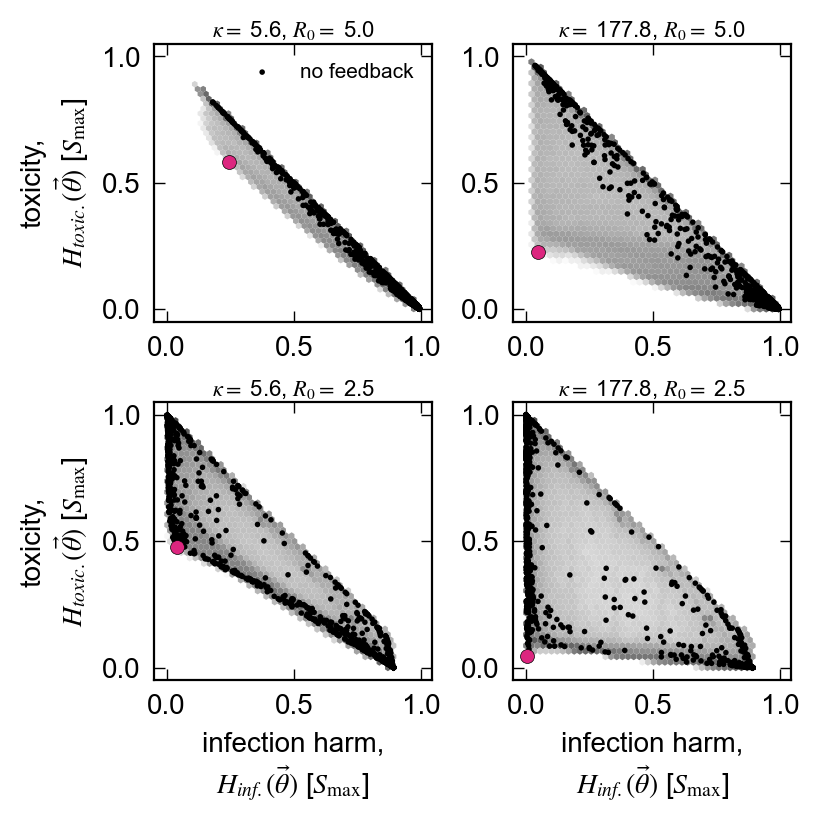

In [9]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2
kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(2, 2, 
                          figsize=(4, 4), sharex=True, sharey=True, layout='constrained')

lambdas = np.linspace(0,1,3)

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    z_label = r"Scaled Harm"

    y, x = k % 2, k // 2
    
    axs[x,y].hexbin(data.peff_infection, data.peff_toxicity,
                       gridsize = 40, C = None,
                         cmap='Grays', edgecolors = 'None',
                   norm = mpl.colors.LogNorm())
    
    # axs[x,y].scatter(data.peff_infection, data.peff_toxicity,
    #               s = 2, color = "gray",
    #               label = 'with feedback',
    #               edgecolors = 'None')

    no_fbk = np.sum(np.abs(data[opt_vars[0:3]]), axis = 1) == 0
    axs[x,y].scatter(data.loc[no_fbk].peff_infection, data.loc[no_fbk].peff_toxicity,
                      s = 4, color = "black",
                      label = 'no feedback',
                      edgecolors = 'None')

    pareto_designs = []
    
    for l in lambdas:
        data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
        data_sorted = data.sort_values(by='compromise', ascending= True).copy()
        max_row = data_sorted.head(10).mean()
        pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

    axs[x,y].scatter(pareto_design_df['peff_infection'].values[int(len(lambdas)/2)], 
                     pareto_design_df['peff_toxicity'].values[int(len(lambdas)/2)],
                     s = 25, marker = 'o',
                     #label = r'$\vec\theta^* = {\rm argmax}~H(\vec\theta)$',
                     color=perf_var_colors[0], zorder = 2, edgecolor = "black", linewidth = 0.25)

    
    axs[x,y].set_title(r"$\kappa=$ "+str(np.round(S_max/a[0],1))+r", $R_0=$ "+str(np.round(a[1],1)), fontsize = 8.0, pad = 2.5)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=10)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)
    
axs[0,0].legend(fontsize=7.5)

for j, ax in enumerate(axs.flat):
    if j // 2 == 1:
        ax.set_xlabel("infection harm,\n"+r'$H_{inf.}(\vec{\theta})$ [$S_\text{max}$]', fontsize = 10)
    if j % 2 == 0:
        ax.set_ylabel("toxicity,\n"+r'$H_{toxic.}(\vec{\theta})$ [$S_\text{max}$]', fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('local/raw_figs/fig3_'+comment+'-singles_clear_tox'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

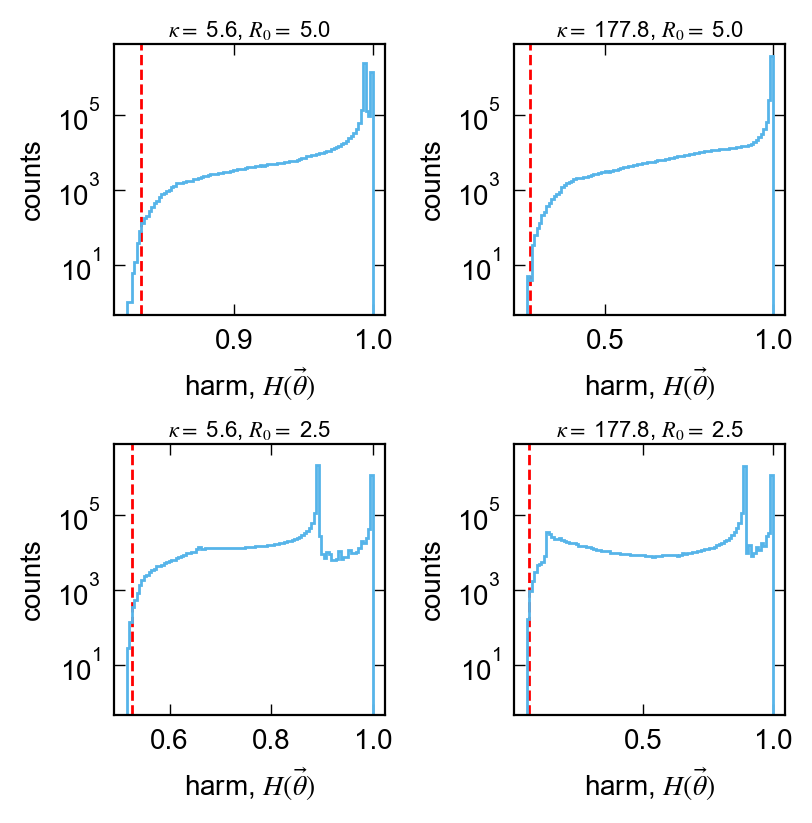

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), sharex=False, sharey=True, layout='constrained')
cluster_tol = 0.01 #10*I_min/S_max

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    y, x = k % 2, k // 2
    sample_std = weighted_std(data[perf_vars[0]], -np.log(data[perf_vars[0]]))

    axs[x,y].hist(data[perf_vars[0]], bins = 100, histtype = 'step', log = True);

    axs[x,y].axvline(x = np.amin(data[perf_vars[0]]) + cluster_tol,
           color = 'red', linewidth = 1.0, alpha = 1.0, linestyle = '--', zorder = 0,
           label = r"near-optimal cutoff")
    
    axs[x,y].set_title(r"$\kappa=$ "+str(np.round(S_max/a[0],1))+r", $R_0=$ "+str(np.round(a[1],1)), #+", STD = "+str(np.round(sample_std,2)), 
                       fontsize = 8.0, pad = 2.5)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=10)
    #axs[x,y].legend()

for j, ax in enumerate(axs.flat):
    ax.set_xlabel(r'harm, $H(\vec{\theta})$', fontsize = 10)
    ax.set_ylabel("counts", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    #ax.semilogx()

plt.savefig('local/raw_figs/figSI_'+comment+'-singles-harm_dist'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

#### Minimize Harm for each infection

In [11]:
# Find optimal designs for each infection by grid searching
grid_opt = pd.concat(Parallel(n_jobs = num_cpu,
                          batch_size = 1)(delayed(grid_search)(g, top = cluster_tol)
                                                   for (_, g) in use_sim_data.groupby(vir_vars)
                                                  ))

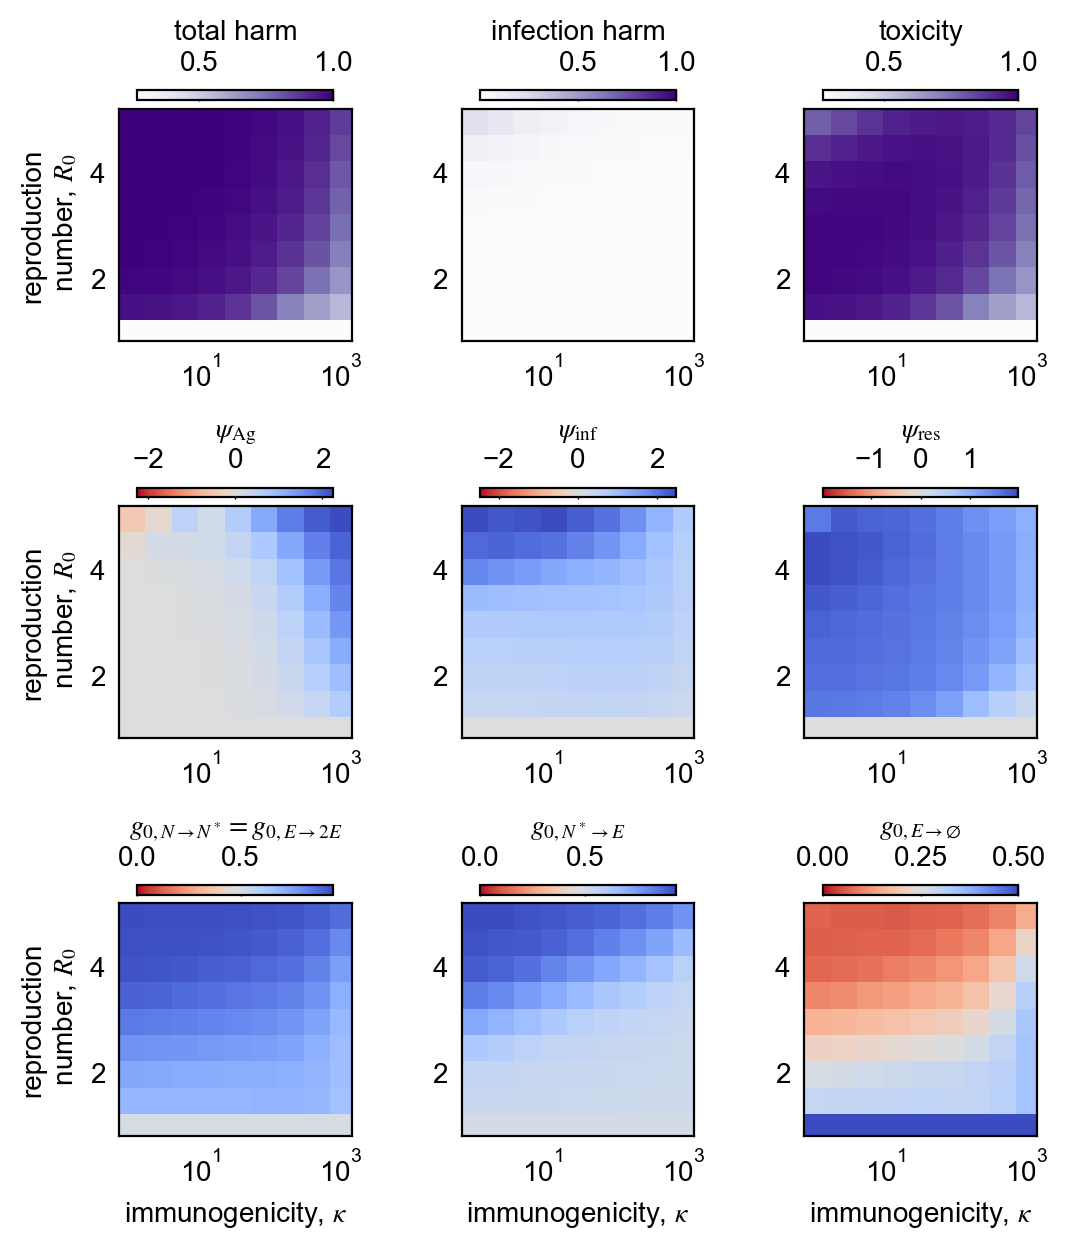

In [12]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 1)].groupby(plots, as_index = False).mean()

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))

    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=10)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

#plt.savefig('local/raw_figs/figSI_'+comment+'-reg-singles_clearance_hmap'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

#### Cluster designs to find infection archetypes

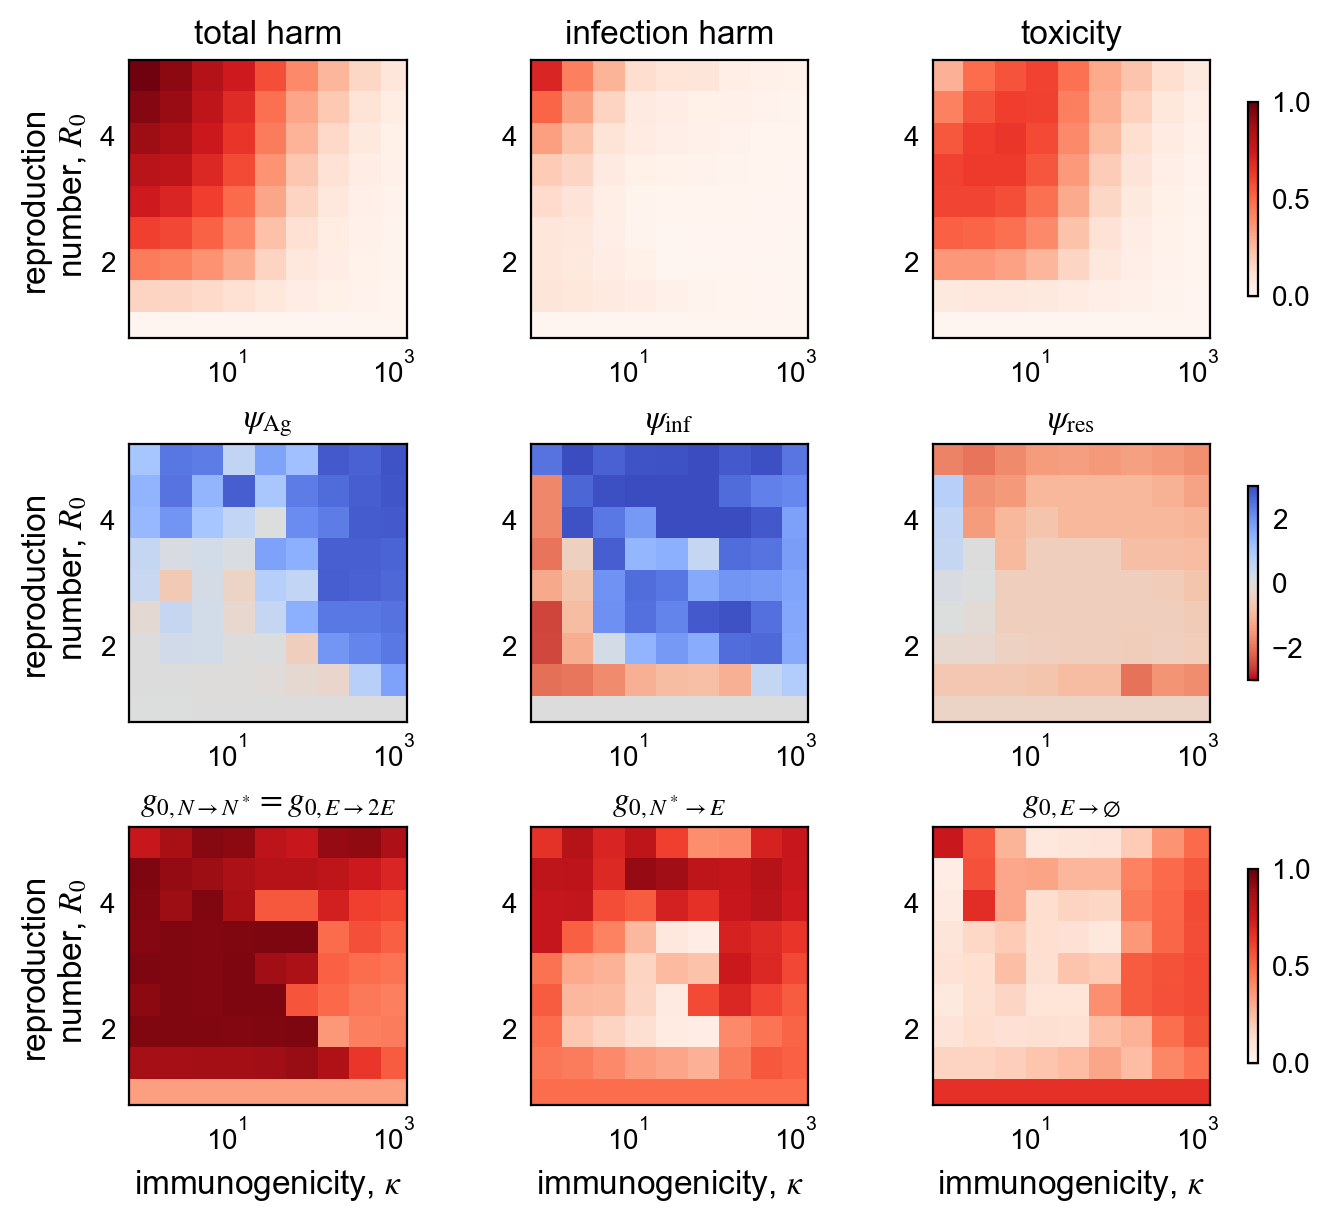

In [13]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6.5, 6), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    # range = np.amax(np.abs(z))

    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap=['Reds','coolwarm_r', 'Reds'][k // 3], edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0.0, vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -psi_max if k < 6 else 0.0, vmax = psi_max if k < 6 else 1.0))

    z_label = ([perf_labels[0], perf_labels[1], perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    ax.set_title(z_label, fontsize = 12.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    
    if k % 3 == 2:
        cb = fig.colorbar(im, ax=axs[k // 3,:], location='right', shrink = 0.7, pad = 0.025)
        # cb.set_label(z_label, fontsize = 10)
        cb.ax.tick_params(labelsize=10)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('local/raw_figs/figSI3_'+comment+'-singles-opt_design-hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

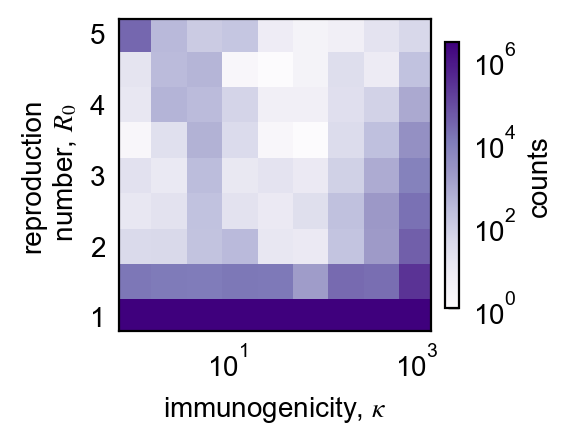

In [14]:
fig, axs = plt.subplots(1,1, figsize=(2.75, 2.75), sharex='row', sharey=False,layout='constrained')

counts = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).size()

im = axs.scatter(S_max/counts[plots[0]], counts[plots[1]],
                 marker ='s', s = size, 
                c = counts['size'], 
            norm = mpl.colors.LogNorm(),
            cmap = 'Purples', edgecolors = 'None')

cb = fig.colorbar(im, ax=axs, location='right', shrink = 0.5, pad = 0.025)
cb.set_label('counts', fontsize = 10)
cb.ax.tick_params(labelsize=10)

axs.semilogx()
axs.minorticks_off()
axs.set_xlabel(plot_labels[0], fontsize = 10)
axs.set_ylabel(plot_labels[1], fontsize = 10)
axs.set_box_aspect(1)
axs.tick_params(axis='both', which='major', labelsize=10)
plt.savefig('local/raw_figs/figSI_'+comment+'-ensemble-sample-counts'+'.pdf', format="pdf", transparent=True, dpi=300)

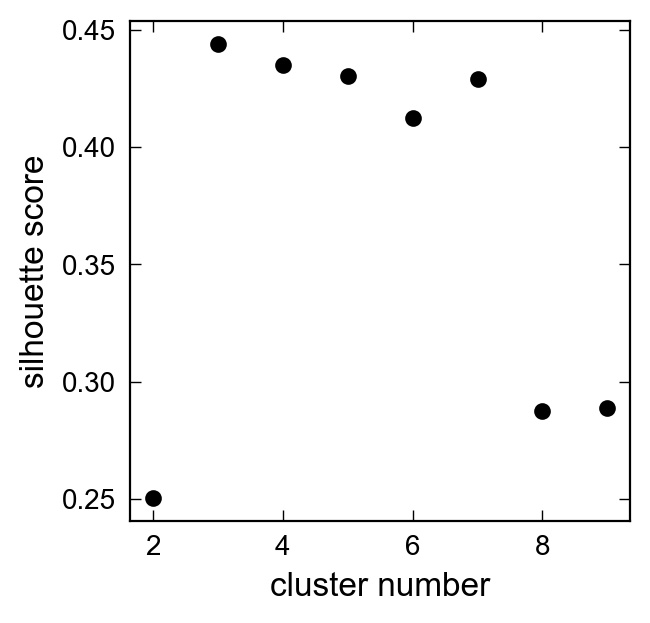

In [15]:
# Set number of clusters
fig, axs = plt.subplots(1,1, figsize=(4, 3.0), sharex='row', sharey=False,layout='constrained')

# Scale and center data for clustering
cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars[0:3] + reg_bl].values)
for_clustering = scaler.transform(cluster_input[opt_vars[0:3] + reg_bl].values)

# compute scores
for k in np.arange(2,10):
    clustering_object = SpectralClustering(n_clusters=k, n_init = 10, random_state=0)
    score = silhouette_score(for_clustering, clustering_object.fit_predict(for_clustering))
    axs.scatter(k,score, color = 'black')

axs.set_xlabel('cluster number', fontsize = 12)
axs.set_ylabel('silhouette score', fontsize = 12)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.tick_params(axis='both', which='major', labelsize=10)

plt.savefig('local/raw_figs/figSI_'+comment+'-cluster_silhouette_scores'+'.pdf', format="pdf", transparent=True, dpi=300)

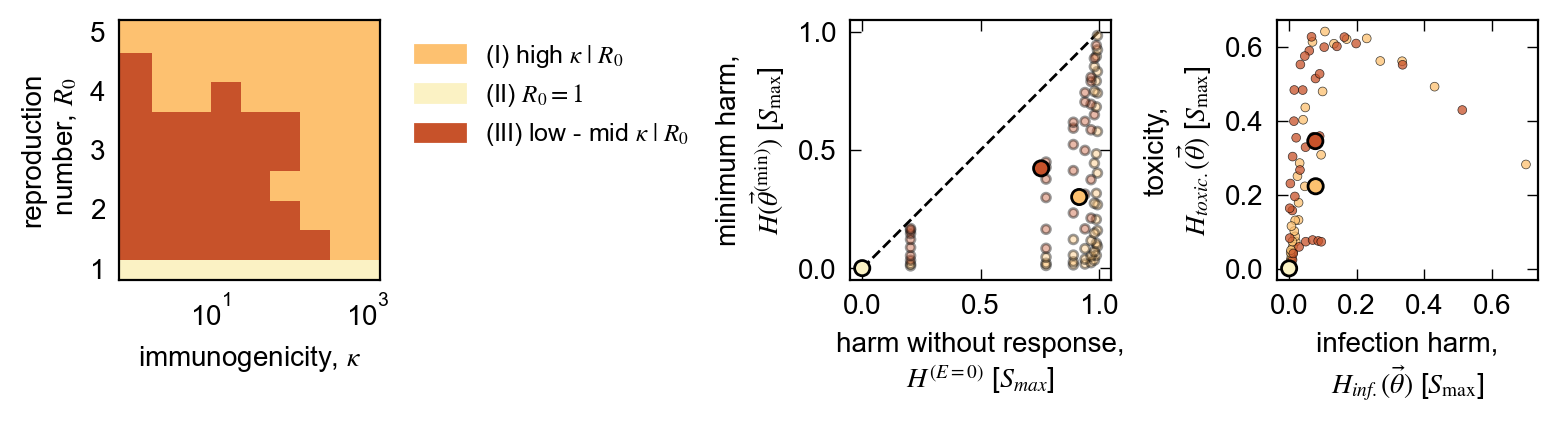

In [16]:
fig, axs = plt.subplots(1, 3, 
                          figsize=(7.75, 2), sharex=False, sharey=False, constrained_layout=True)

size = 1000/np.cbrt(n_virs)

cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars[0:3] + reg_bl].values) # ['K_I', plots[1]] + ['peff_infection', 'peff_toxicity']
for_clustering = scaler.transform(cluster_input[opt_vars[0:3] + reg_bl].values) # ['K_I', plots[1]]  + ['peff_infection', 'peff_toxicity']
clustering_object = SpectralClustering(n_clusters=3, n_init = 10,
        random_state=0)
clustering = clustering_object.fit(for_clustering)

cluster_input.loc[:,'raw_cluster'] = clustering.labels_
assign_phase = cluster_input.groupby(['raw_cluster'], 
                                     as_index = False).mean().sort_values(by=plots, 
                                                                          ascending= True).reset_index(drop=True)[plots + ['raw_cluster']]
cluster_input.loc[:,'phase_cluster'] = np.array([assign_phase.loc[assign_phase.raw_cluster == p].index.tolist()[0] for p in cluster_input.raw_cluster.values]) #clustering.labels_

## Make plots
# (a) Plot infection clusters
axs[0].scatter(S_max/cluster_input[plots[0]], cluster_input[plots[1]],
                 marker ='s', s = size, 
                c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values], 
                 edgecolors = 'None')

axs[0].set_xlabel(plot_labels[0], fontsize = 10)
axs[0].set_ylabel(plot_labels[1], fontsize = 10)
axs[0].locator_params(axis='y', nbins=6)
axs[0].semilogx()

legend_handles = []
phase_clusters = np.unique(cluster_input['phase_cluster'].values)
phase_cluster_labels = [r"(I) high $\kappa~|~R_0$", r"(II) $R_0 = 1$", r"(III) low - mid $\kappa~|~R_0$"] #, r"(IV) low $\kappa$"] #, r"(V)"] #, '(VI)']
n_clusters = len(phase_clusters)
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

axs[0].legend(handles=legend_handles, bbox_to_anchor=(1.05, 1.0), fontsize=9, framealpha=0, ncol = 1)

# (b) Plot optimized and unoptimized harm
plot_data = cluster_input.groupby('phase_cluster', as_index = False).mean()

axs[1].scatter(plot_data.harm_pI_noprotection, 
               plot_data.peff_total_harm,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[1].scatter(cluster_input.harm_pI_noprotection, 
               cluster_input.peff_total_harm,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.4)

axs[1].plot([0,1], [0,1], color = 'black', linestyle = '--', zorder = 0, label=r'slope $= 1$')
axs[1].locator_params(axis='x', nbins=4)
axs[1].locator_params(axis='y', nbins=4)
axs[1].set_xlabel("harm without response,\n"+r'$H^{(E = 0)}$ [$S_{max}$]', fontsize = 10)
axs[1].set_ylabel("minimum harm,\n"+r'$H(\vec\theta^{(\text{min})})$ [$S_\text{max}$]', fontsize = 10)

# (c) Plot optimized infection and toxicity
axs[2].scatter(plot_data.peff_infection, #/plot_data.harm_pI_noprotection, 
               plot_data.peff_toxicity, #/plot_data.harm_pI_noprotection,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[2].scatter(cluster_input.peff_infection, #/cluster_input.harm_pI_noprotection, 
               cluster_input.peff_toxicity, #/cluster_input.harm_pI_noprotection,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               linewidth = 0.25,
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.75)

# axs[2].plot([0,1], [1,0], color = 'black', linestyle = '--', zorder = 0, label=r'slope $= -1$')

axs[2].locator_params(axis='x', nbins=4)
axs[2].locator_params(axis='y', nbins=4)

axs[2].set_xlabel("infection harm,\n"+r'$H_{inf.}(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)
axs[2].set_ylabel("toxicity,\n"+r'$H_{toxic.}(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)

for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.savefig('local/raw_figs/fig3_'+comment+'-optimal-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

The optimal response depends on the Immunogenicity of the pathogens encountered. The optimal design of the response to high Immunogenicity pathogens demonstrates the logic that the system should be tuned to respond to threats that it can easily detect.

In [17]:
# Add cluster information to data
cluster_sim_df = use_sim_data.merge(cluster_input[['idx','phase_cluster']], how = 'left', on = ['idx'])
#cluster_sim_df.loc[:,'phase_cluster'] = cluster_sim_df.apply(lambda row: int(np.mean(cluster_input.phase_cluster.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))])), axis = 1)

# Compute design performance in each cluster
avg_cluster_data = cluster_sim_df.groupby(opt_vars + ['phase_cluster'], as_index = False).mean()

In [18]:
check_merge = cluster_sim_df.loc[np.isnan(cluster_sim_df.phase_cluster.values)]
len(check_merge)

0

In [19]:
# Compute optimal performance as a function of allowed feedback strength
cluster_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = cluster_tol)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'],as_index = False)
                                                  ))

# Compute optimal performance as a function of each individual single design 
cluster_ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 0.00)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'], as_index = False)
                                                  ))

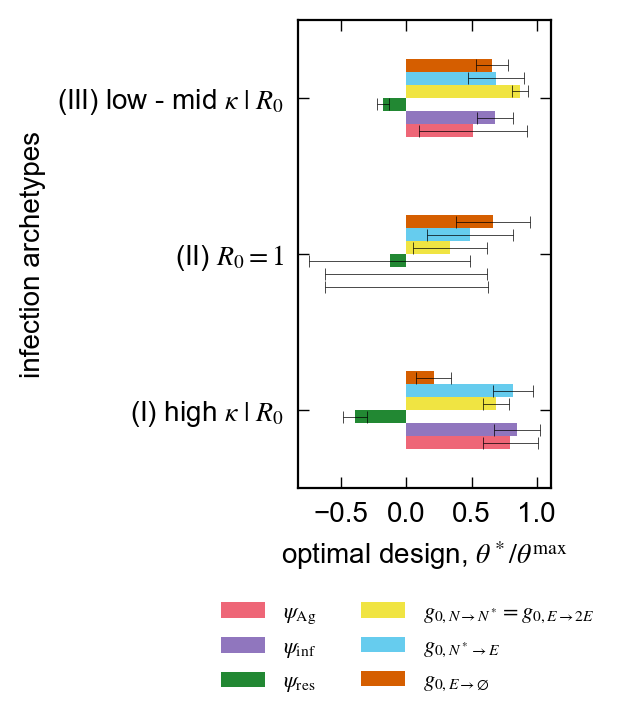

In [20]:
# Prepare data
row_labels = opt_vars_labels
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean()[opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).tolist()
std_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).std()[opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).tolist()
# Plot optimal designs
fig, axs = plt.subplots(1,1, figsize=(3.0, 3.5), sharex='row', sharey=False,layout='constrained')

df = pd.DataFrame(opt_reg_data, index=phase_cluster_labels, columns = opt_vars_labels)
std_df = pd.DataFrame(std_reg_data, index=phase_cluster_labels, columns = opt_vars_labels)

df.plot.barh(ax=axs, color = cmap_colors, xerr = std_df, error_kw=dict(lw=0.25, capsize=2, capthick=0.25))
axs.set_xlabel(r"optimal design, $\theta^*/\theta^\text{max}$", fontsize = 10)
axs.legend(bbox_to_anchor=(1.25, -0.20), ncol = 2, fontsize=8)

axs.minorticks_off()
axs.tick_params(axis='both', which='major', labelsize=10)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=6)
axs.locator_params(axis='x', nbins=5)
axs.set_ylabel('infection archetypes', fontsize = 10)
#axs.set_xticklabels(col_labels, rotation='horizontal', size = 8)

fig.savefig('local/raw_figs/fig3_'+comment+'-cluster_opt-reg_bars'+'.pdf', format="pdf", transparent=True, dpi=150)

### (b) Pareto optimization of the immune response

#### Compare archetypes pairwise

KeyboardInterrupt: 

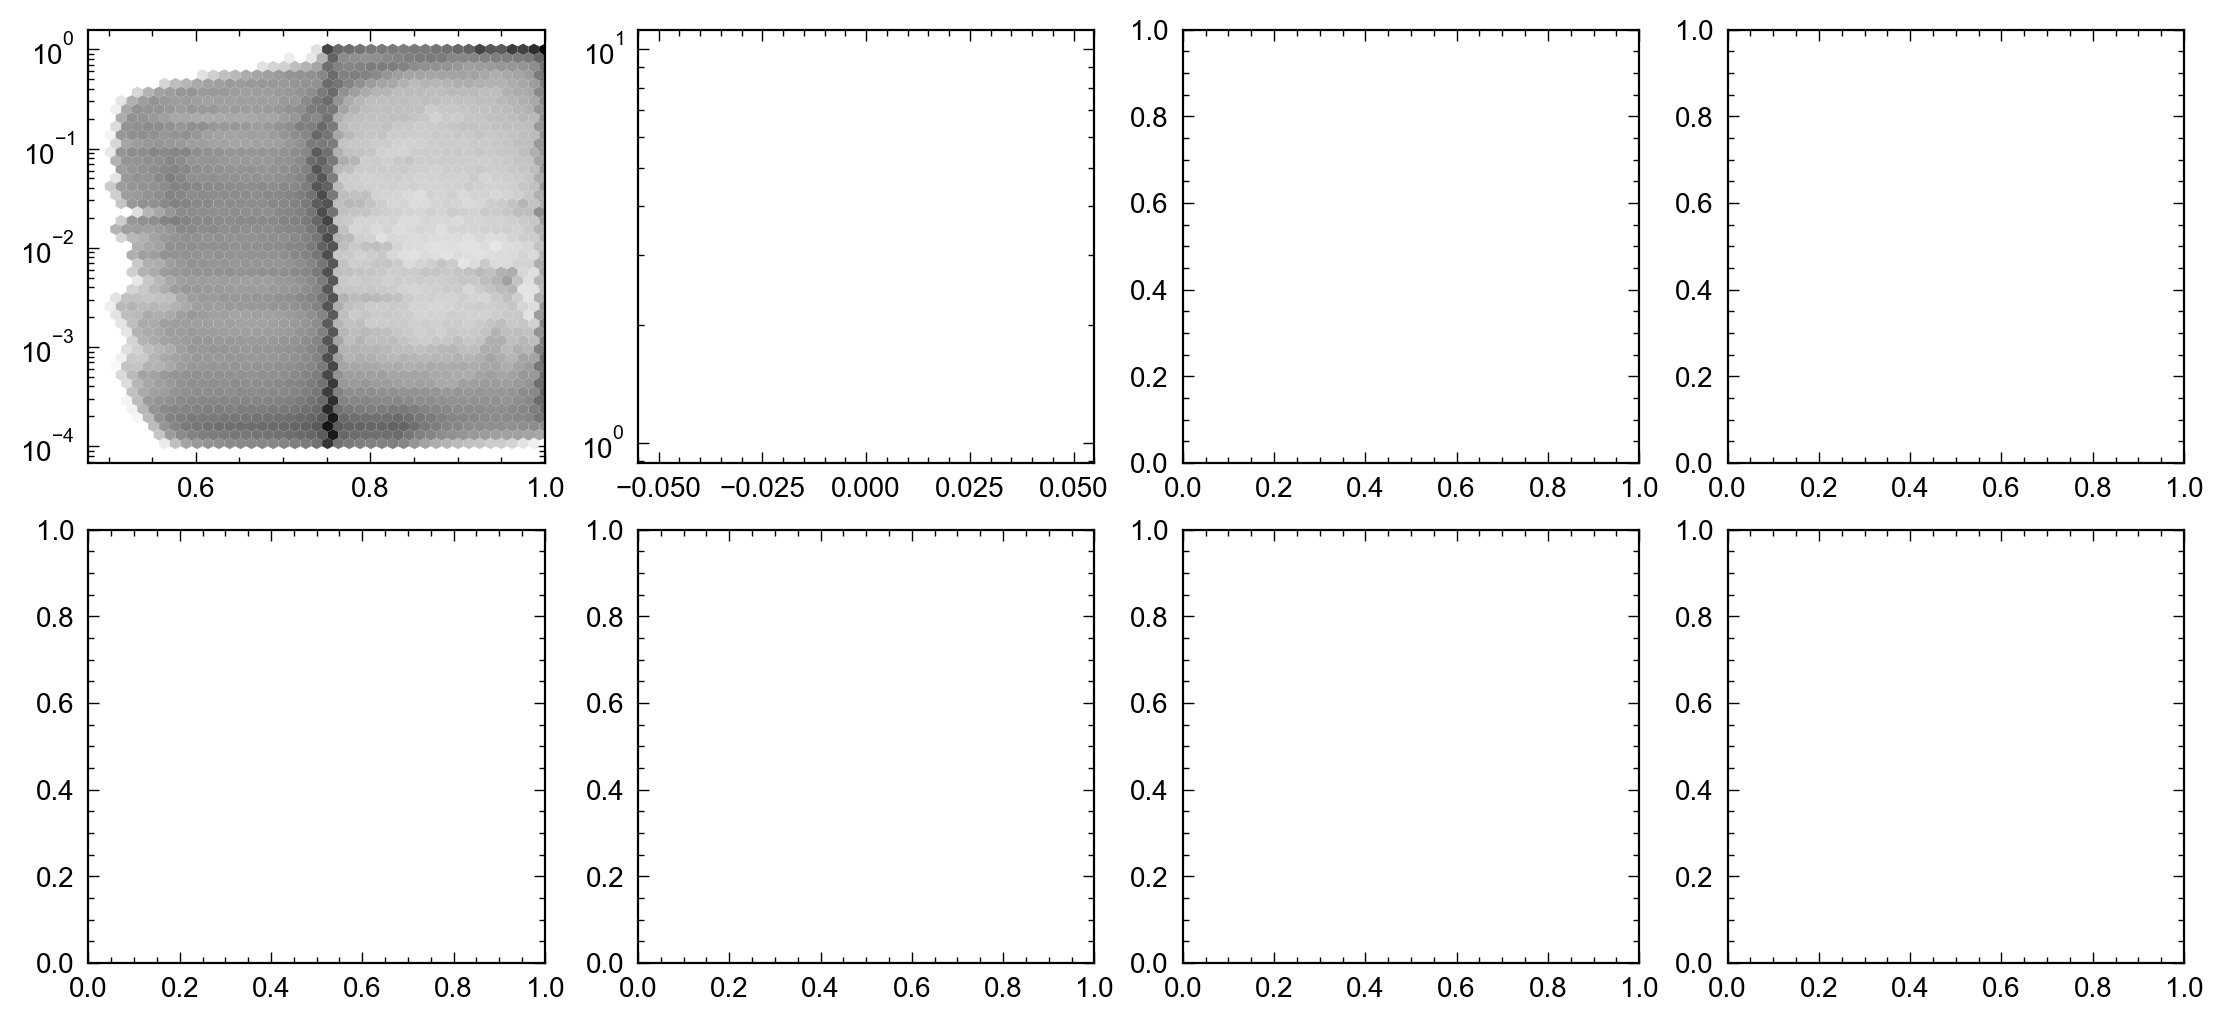

In [21]:
# Visualize pareto regulation
perf_var = 'peff_total_harm'
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

subsets = [[2,1], [2,0]] #, [4,0]]
fig, axs = plt.subplots(len(subsets), 4, figsize=(11, len(subsets)*2.5), sharex=False, sharey=False,layout='constrained')

tol = 0.05 # sets upper bound of harm

for k, [a, b] in enumerate(subsets):
    # (a) Effect of H_E ablation on Harm
    a_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == a)]
    b_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)]
    
    plot_data = a_group.merge(b_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))
    
    im = axs[k,0].hexbin(plot_data[perf_var].values, 
                         plot_data[perf_var+'_comp'].values,
                         gridsize = 40, C = None, yscale='log' if b == 1 else 'linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    if b != 1:
        lambdas = np.linspace(0,1, 51)
    else:
        lambdas = np.logspace(-7,0, 51)
        axs[k,0].semilogy()
        axs[k,1].semilogy()
    axs[k,0].set_xlim(None,1.0)


    pareto_designs = []
    mean_pareto_designs, max_pareto_designs, min_pareto_designs, std_pareto_designs = [], [], [], []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = l*plot_data[perf_var].values + (1-l)*plot_data[perf_var+'_comp'].values
        plot_data.loc[:,'lambda'] = l
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        near_rows= data_sorted.loc[(data_sorted[perf_var] <= (1 + tol)*data_sorted[perf_var].values[0])*(data_sorted[perf_var+'_comp'] <= (1 + tol)*data_sorted[perf_var+'_comp'].values[0])]
        opt_row = near_rows.head(1) # data_sorted.head(1).mean() # 
        mean_row = near_rows.mean()
        max_row = near_rows.max()
        min_row = near_rows.min()
        std_row = near_rows.std()
        pareto_designs.append(opt_row.values)
        mean_pareto_designs.append(mean_row.values)
        max_pareto_designs.append(max_row.values)
        min_pareto_designs.append(min_row.values)
        std_pareto_designs.append(std_row.values)
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
    mean_pareto_design_df = pd.DataFrame(np.vstack(mean_pareto_designs), columns = data_sorted.columns.tolist())
    max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
    min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())
    std_pareto_design_df = pd.DataFrame(np.vstack(std_pareto_designs), columns = data_sorted.columns.tolist())

    # Identify elbow
    x,y,l = pareto_design_df.loc[pareto_design_df[perf_var+'_comp'] <= (1e-2 if b == 1 else 1.0), [perf_var, perf_var+"_comp", 'lambda']].drop_duplicates([perf_var, perf_var+"_comp"]).values.T # dedupe pareto points
    kn = KneeLocator(x, y, curve='convex', direction='decreasing', online = True)
    elbow_design = pareto_design_df.loc[np.abs(pareto_design_df[perf_var] - kn.knee).idxmin()]
    
    axs[k,0].plot(pareto_design_df[perf_var].values, 
                  pareto_design_df[perf_var+'_comp'].values,
                  color=perf_var_colors[0], linewidth = 2.5, alpha = 1.0,
               label = "Pareto")
    
    axs[k,0].scatter(elbow_design[perf_var],
                     elbow_design[perf_var+'_comp'],
                   label = r"elbow",
           s = 20,
                     marker = 's',
       color='None', edgecolors = 'black', zorder = 2, linewidth = 1.0)
    
    for l, perf in enumerate([perf_var]+perf_vars[1:3]):
        
        axs[k,1].plot(pareto_design_df[perf_var].values,
                      pareto_design_df[perf+'_comp'].values, #/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                      color = perf_var_colors[l],
                    zorder = 3 - l,
                    label = perf_labels[l], 
                    **kwargs)
    
    for i, var in enumerate(opt_vars):
        if i < 3:
            axs[k,2].fill_between(pareto_design_df[perf_var].values,
                                  (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,2].plot(pareto_design_df[perf_var].values,
                          mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)
    
        if i >= 3:
            axs[k,3].fill_between(pareto_design_df[perf_var].values, 
                                  (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,3].plot(pareto_design_df[perf_var].values,
                          mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)

    axs[k,0].set_ylabel('archetype '+phase_cluster_labels[b]+",\n"+r"$H(\vec\theta)$", fontsize = 12)
    axs[k,0].set_xlabel('archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 12)
    
    axs[k,1].set_ylabel('archetype '+phase_cluster_labels[b]+",\n"+r"$H(\vec\theta)$", fontsize = 12)
    axs[k,1].set_xlabel('archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 12)

    axs[k,2].set_xlabel('archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 12)
    axs[k,2].set_ylabel("sensitivity, "+ r"$\psi$", fontsize = 12)
    axs[k,2].set_ylim(-1.0, 1.1)
    axs[k,3].set_xlabel(phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 12)
    axs[k,3].set_ylabel("baseline, "+ r"$g_0$", fontsize = 12)
    axs[k,3].set_ylim(0.0, 1.1)

axs[0,0].legend(loc='upper right',fontsize=10, framealpha=0, ncol = 1)
axs[0,1].legend(fontsize=9, framealpha=0, ncol = 1)
axs[0,2].legend(fontsize=9) #bbox_to_anchor=(1.0, 1), 
axs[0,3].legend(fontsize=9) # bbox_to_anchor=(1.0, 1), 
#axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('local/raw_figs/figSI6_'+comment+'-pareto-harm_compare_clusters'+'.pdf', format="pdf", transparent=True, dpi=150) #, bbox_inches="tight")

In [ ]:
# Visualize pareto regulation
perf_var = 'peff_total_harm'
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(1, 4, figsize=(11, 2), sharex=False, sharey=False, layout='constrained')
tol = 0.05
lambdas = np.logspace(-7,0, 51)
ag_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 0)]
lowR0_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 1)]

plot_data = ag_group.loc[ag_group[perf_var].values > 0].merge(lowR0_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

im = axs[0].hexbin(plot_data[perf_var].values,
                     plot_data[perf_var+'_comp'].values,
                     gridsize = 40, C = None,  yscale='log',
                     cmap='Grays', edgecolors = 'None',
                     norm = mpl.colors.LogNorm())

pareto_designs = []
ensemble_pareto_designs = []
mean_pareto_designs, max_pareto_designs, min_pareto_designs, std_pareto_designs = [], [], [], []

# In
for l in lambdas:
    plot_data.loc[:,'compromise'] = l*plot_data[perf_var].values + (1-l)*plot_data[perf_var+'_comp'].values
    plot_data.loc[:,'lambda'] = l
    data_sorted = plot_data.sort_values(by='compromise', ascending= True)
    near_rows= data_sorted.loc[(data_sorted[perf_var] <= (1 + tol)*data_sorted[perf_var].values[0])*(data_sorted[perf_var+'_comp'] <= (1 + tol)*data_sorted[perf_var+'_comp'].values[0])]
    opt_row = near_rows.head(1) # data_sorted.head(1).mean() # 
    mean_row = near_rows.mean()
    max_row = near_rows.max()
    min_row = near_rows.min()
    std_row = near_rows.std()
    pareto_designs.append(opt_row.values)
    mean_pareto_designs.append(mean_row.values)
    max_pareto_designs.append(max_row.values)
    min_pareto_designs.append(min_row.values)
    std_pareto_designs.append(std_row.values)
    ensemble_pareto_designs.append(near_rows.values)

pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
mean_pareto_design_df = pd.DataFrame(np.vstack(mean_pareto_designs), columns = data_sorted.columns.tolist())
max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())
std_pareto_design_df = pd.DataFrame(np.vstack(std_pareto_designs), columns = data_sorted.columns.tolist())
ensemble_pareto_design_df = pd.DataFrame(np.vstack(ensemble_pareto_designs), columns = data_sorted.columns.tolist())

# Identify elbow
x,y,l = pareto_design_df.loc[pareto_design_df[perf_var+'_comp'] < 1e-2, [perf_var, perf_var+"_comp", 'lambda']].drop_duplicates([perf_var, perf_var+"_comp"]).values.T # dedupe pareto points
kn = KneeLocator(x, y, curve='convex', direction='decreasing', online = True)
elbow_design = pareto_design_df.loc[np.abs(pareto_design_df[perf_var] - kn.knee).idxmin()]
ensemble_elbow_design = ensemble_pareto_design_df.loc[ensemble_pareto_design_df['lambda'] == elbow_design['lambda']]

axs[0].plot(pareto_design_df[perf_var].values, 
              pareto_design_df[perf_var+'_comp'].values,
              color=perf_var_colors[0], linewidth = 2.5, alpha = 1.0,
           label = "Pareto")

axs[0].scatter(elbow_design[perf_var], 
               elbow_design[perf_var+'_comp'],
               label = r"elbow",
       s = 25,
       marker = 's',
       color='None', edgecolors = 'black', zorder = 2, linewidth = 1.0)

axs[0].set_xlim(None, None)
axs[0].set_ylim(2e-5, None)

for l, perf in enumerate([perf_var] + perf_vars[1:3]):
     
    axs[1].plot(pareto_design_df[perf_var].values,
                pareto_design_df[perf+'_comp'].values,
                  color = perf_var_colors[l],
                zorder = 3 - l,
                label = perf_labels[l], 
                **kwargs)

for i, var in enumerate(opt_vars):
    if i < 3:
        axs[2].fill_between(pareto_design_df[perf_var].values,
                            (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[2].plot(pareto_design_df[perf_var].values,
                      mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

    if i >= 3:
        axs[3].fill_between(pareto_design_df[perf_var].values,
                            (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[3].plot(pareto_design_df[perf_var].values,
                      mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

axs[1].axvline(x = elbow_design[perf_var], 
               color = 'black', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0,
               label = r"Pareto elbow")
axs[2].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)
axs[3].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)
axs[1].semilogy()

axs[0].set_ylabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_{max}$]", fontsize = 10)
axs[0].set_xlabel('harm, archetype I\n'+r"$H^{(\text{I})}(\vec\theta)$ [$S_\text{max}$]", fontsize = 10)

axs[1].set_ylabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_{max}$]", fontsize = 10)
axs[1].set_xlabel('harm, archetype I\n'+r"$H^{(\text{I})}(\lambda)$ [$S_\text{max}$]", fontsize = 10)

axs[2].set_xlabel('harm, archetype I\n'+r"$H^{(\text{I})}(\lambda)$ [$S_\text{max}$]", fontsize = 10)
axs[2].set_ylabel("sensitivity, "+ r"$\psi$", fontsize = 10)
axs[2].set_ylim(-1.0, 1.1)

axs[3].set_xlabel('harm, archetype I\n'+r"$H^{(\text{I})}(\lambda)$ [$S_\text{max}$]", fontsize = 10)
axs[3].set_ylabel("baseline, "+ r"$g_0$", fontsize = 10)
axs[3].set_ylim(.0, 1.1)

axs[0].legend(fontsize=8, loc='upper left', framealpha=0, markerfirst= False, labelcolor = 'black')
axs[1].legend(fontsize=7, framealpha=0)
axs[2].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)
axs[3].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('local/raw_figs/fig4_'+comment+'-pareto_harm'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

In [ ]:
mean_pareto_design_df.drop_duplicates(opt_vars[0:3] + reg_bl)['lambda'].values

In [ ]:
# Inspect elbow
new_kn = KneeLocator(x, y, curve='convex', direction='decreasing', 
                     S = 1.0, online = True)
new_kn.plot_knee()
plt.plot(x, y, 'o')
#plt.semilogy()
print(new_kn.knee)

#### Store elbow regulatory design

In [ ]:
# Print full ensemble
ensemble_elbow_design.to_pickle(DATA_DIR+'/ensemble_elbow_design'+'-'+model+'.pkl')
print('lambda: ',elbow_design['lambda'], 
      ', ensemble size: ', len(ensemble_elbow_design))
ensemble_elbow_design[opt_vars[0:3] + reg_bl + [perf_vars[0], perf_vars[0]+'_comp']].drop_duplicates() #.to_latex() 

In [ ]:
# Set representative ensemble
ensemble_pareto_reg = ensemble_elbow_design[opt_vars[0:3] + reg_bl].values
avg_pareto_reg = np.mean(ensemble_pareto_reg, axis = 0) # elbow_design[opt_vars[0:3] + reg_bl].values
ensemble_pareto_range = np.array([ensemble_pareto_reg[0], avg_pareto_reg])
print(avg_pareto_reg)
print(np.std(ensemble_pareto_reg, axis = 0))

#### Explore performance of (I)-(II) optimized response

In [ ]:
runs = 10
ps = ensemble_pareto_reg

psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
                 ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
                 -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**4 -0*ps[:,4], # EM
                 -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

sample = np.array(np.meshgrid(np.unique(grid_opt.b_I), # vary b_I
                                   np.unique(grid_opt.K_I), # vary K_I
                                   np.unique(grid_opt.d_I), # vary d_I
                                   np.unique(grid_opt.K_H), # vary K_H
                                   np.unique(grid_opt.N_0), # vary N_0
                                   np.unique(grid_opt.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]), # vary max_expand
                                        np.array([sim_duration]) # vary simulation time
                                           )).T.reshape(-1,12)


# run simulations for extreme scenarios
# run(batch = [-1], outdir=DATA_DIR, inf_sample = sample, 
#     comment="pareto_reg_sim"+'-'+model, runs = runs, infection_model = 'acute', 
#     default_reg = psis,
#     num_cpu = num_cpu)

d_file = DATA_DIR + '/sim_batch_-1-10-acute-pareto_reg_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
crit_reg_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]) #.merge(cluster_input[['K_I', 'b_I'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I'])

crit_reg_data.loc[:, 'R_0'] = S_max*crit_reg_data['b_I']/crit_reg_data['d_I']
crit_reg_data.loc[:,opt_vars[0:3]] = np.round(crit_reg_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
crit_reg_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-crit_reg_data[reg_bl].values)), 3)
crit_reg_data.loc[:,"harm_pI_noprotection"] = crit_reg_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

crit_reg_data.loc[:,"peff_infection"] = crit_reg_data['harm_pI']/S_max
crit_reg_data.loc[:,"peff_toxicity"] = crit_reg_data['harm_pS']/S_max
crit_reg_data.loc[:,"peff_total_harm"] = crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity']
crit_reg_data.loc[:,"peff_scaled_total_harm"] = (crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity'])/crit_reg_data["harm_pI_noprotection"]

crit_eff_dyn_design = crit_reg_data.groupby(plots, as_index = False, sort = True).mean()
crit_eff_dyn_design.loc[:,"phase_cluster"] = cluster_input.phase_cluster.values
std_crit_eff_dyn_design = crit_reg_data.groupby(plots + opt_vars, as_index = False, sort = True).std().groupby(plots, as_index = False, sort = True).mean()
std_crit_eff_dyn_design.loc[:,"phase_cluster"] = cluster_input.phase_cluster.values
#crit_eff_dyn_design = cluster_sim_df.loc[np.sum(np.abs(cluster_sim_df[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == 0]
crit_eff_dyn_design.loc[:,"phase_cluster"] = cluster_input.phase_cluster.values
crit_eff_dyn_design.loc[:,"del_peff_total_harm"] = crit_eff_dyn_design.peff_total_harm.values - cluster_input.peff_total_harm.values
crit_eff_dyn_design.loc[:,"del_peff_infection"] = (crit_eff_dyn_design.peff_infection - cluster_input.peff_infection.values)
crit_eff_dyn_design.loc[:,"del_peff_toxicity"] = (crit_eff_dyn_design.peff_toxicity - cluster_input.peff_toxicity.values) #/crit_eff_dyn_design.harm_pI_noprotection

In [ ]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(1, 3, 
                          figsize=(6, 2), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = ['del_peff_total_harm', 'del_peff_infection', 'del_peff_toxicity'] # 'harm_pI_noprotection'
data = crit_eff_dyn_design

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))
    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='coolwarm', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    z_label = ([r'$H^{(\text{elbow})}-H^{(\text{min})}$',
                r'$H_{\text{inf.}}^{(\text{elbow})}-H_{\text{inf.}}^{(\text{min})}$',
                r'$H_{\text{toxic.}}^{(\text{elbow})}-H_{\text{toxic.}}^{(\text{min})}$'])[k]
    ax.set_title(z_label, fontsize = 12.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    cb = fig.colorbar(im, ax=ax, location='right', shrink = 0.6, pad = 0.025)
    # cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=10)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('local/raw_figs/figSI_'+comment+'-singles-pareto-delta_harm-hmap'+'.pdf', dpi=300) #, bbox_inches="tight")

In [ ]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(1, 2, 
                          figsize=(5, 2), sharex=True, sharey=False, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = ['peff_total_harm', 'max_pE'] # 'harm_pI_noprotection'
data = crit_eff_dyn_design.groupby(plots[0], as_index = False).mean()
std_data = std_crit_eff_dyn_design.groupby(plots[0], as_index = False).mean()
y_labels = [perf_labels[0]+r' [$S_{\rm max}$]', 'peak \n'+ r'effector count [$S_\text{max}$]']

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))
    cv = np.mean(std_data[var])/np.mean(data[var])
    im = ax.plot(S_max/data[plots[0]], z, label = r'C.V. $=$ '+str(np.round(cv, 2)))

    ax.fill_between(S_max/data[plots[0]],
                        (z + std_data[var].values),
                        (z - std_data[var].values),
                                alpha=0.2)

    
    ax.set_box_aspect(1)
    ax.legend(fontsize = 8)
    ax.semilogx()
    if k == 1:
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(y_labels[k], fontsize = 12)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

# print('coefficient of variation: ',elbow_design['lambda'], 
#       ', ensemble size: ', len(ensemble_elbow_design))

plt.savefig('local/raw_figs/figSI12_'+comment+'-pareto-simulation-noise'+'.pdf', dpi=300) #, bbox_inches="tight")

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 2.5), sharey = False, constrained_layout=True)
plot_data = crit_eff_dyn_design.groupby(['phase_cluster'], as_index = False).mean() # avg_cluster_data.loc[np.sum(np.abs(avg_cluster_data[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == 0]
std_data = std_crit_eff_dyn_design.groupby(['phase_cluster'], as_index = False).mean()

axs[0].scatter(plot_data.peff_total_harm.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               marker = 's',
               label = 'Pareto elbow-optimum', #r'Pareto, $\vec\theta^{(\text{elbow})}$',
               s = 35, edgecolors = 'black', zorder = 2, alpha = 1.0)

axs[0].scatter(cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'], as_index = False).mean().peff_total_harm.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               marker = 'o',
               label = 'archetype optimum', #r'minimizer, $\vec\theta^{(\text{min})}$',
               s = 35, edgecolors = 'black', zorder = 2, alpha = 1.0)

axs[0].set_xlabel('harm, '+r'$H(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)
axs[0].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)
axs[0].locator_params(axis='x', nbins=6)

axs[1].scatter((plot_data.peff_total_harm.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean().peff_total_harm.values), #/plot_data.harm_pI_noprotection.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[1].scatter(crit_eff_dyn_design.peff_total_harm/cluster_input.peff_total_harm.values, crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[1].set_xlabel('relative total harm,\n'+r'$H^{(elbow)}/H^{(*)}$', fontsize = 10)
axs[1].set_xlim(0.0, None)
axs[1].locator_params(axis='x', nbins=6)
axs[1].axvline(x = 1.0, color = 'black', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)

# axs[1].set_xlim(0.0, None)

axs[2].scatter((plot_data.max_pE.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean().max_pE.values),
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[2].scatter((crit_eff_dyn_design.max_pE.values/cluster_input.max_pE.values), 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[2].set_xlabel('effector fold change,\n $E_{max}^{(elbow)}/E_{max}^{(*)}$', fontsize = 10)
axs[2].semilogx()

axs[3].scatter(plot_data.max_pE.values/N_0,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[3].scatter(crit_eff_dyn_design.max_pE.values/N_0, 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[3].set_xlabel('effector expansion,\n'+ r'$E_{max}^{(elbow)}$ [$N_\text{lin.}$]', fontsize = 12)
axs[3].semilogx()

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.set_ylabel('infection archetype', fontsize = 12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_yticks(phase_clusters, phase_cluster_labels, rotation = 0)
    ax.xaxis.set_tick_params(labeltop=False)
    #ax.locator_params(axis='x', nbins=4)

fig.savefig('local/raw_figs/fig4_'+comment+'-cluster_opt-pareto-delta_harm'+'.pdf', format="pdf", transparent=True, dpi=300)

### (c) Relationship between parameter values and performance

In [ ]:
# Compute optimal performance as a function of allowed feedback strength
cluster_feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 0.00)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster', 'feedback'],as_index = False)
                                                  ))

In [ ]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)].groupby(['phase_cluster', 'feedback'], as_index = False).mean()

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, perf in enumerate(perf_vars[0:3]):
        axs.flat[k].plot(g['feedback'].values,
             g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
             color = perf_var_colors[i],
                            **kwargs)
    
        axs.flat[k].scatter(g['feedback'].values,
         g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
         color = perf_var_colors[i], 
         label = perf_labels[i])

    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)

for ax in axs.flat: 
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel(r"Optimal performance, $H$", fontsize = 10)
    ax.set_xlabel(r"Sensitivity, $|\psi_{max}|$", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('local/raw_figs/figSI_'+comment+'-cluster_harm-vary_sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

Paradoxically, for a response to be protective, it drives down the infection feedback signals.

##### Relationship between design and performance

In [ ]:
# Make trade-off figure
fig, axs = plt.subplots(len(opt_vars),n_clusters, figsize=(n_clusters*2 + 3, len(opt_vars)*2 + 3), sharex='row', sharey='col',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]
opt_reg_data = cluster_grid_opt.loc[(cluster_grid_opt.perf_index == 0)].groupby(['phase_cluster'], as_index = False).mean()

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars):
        use_data = g.groupby([var, 'ablate_index'], as_index = False).mean()
        for x, u in enumerate(perf_vars[0:3]):
            axs[i,k].plot(use_data.loc[(use_data.ablate_index == i),  [var]].values,
                 use_data.loc[(use_data.ablate_index == i), [u]].values,
                 color = perf_var_colors[x], 
                             label = perf_labels[x],
                                **kwargs)

        axs[i,k].axvline(x = opt_reg_data.loc[opt_reg_data.phase_cluster == k][var].values[0], 
                         color = 'grey', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0,
                        label = 'ensemble average')
        axs[i,k].set_xlabel(opt_vars_labels[i], fontsize = 14)
        if k == 0 and i == 0:
            axs[i,0].legend(fontsize=12, framealpha=0, ncol = 1)

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs[0,k].set_title(phase_cluster_labels[k], fontsize = 14.0)

            
axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    # if k // 3 == 2:
    #     ax.set_xlabel(plot_labels[0], fontsize = 10)
    if j % n_clusters == 0:
        ax.set_ylabel(r"harm, $H_{(\cdot)}(\vec\theta)$", fontsize = 14)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('local/raw_figs/figSI4-5_'+comment+'-cluster_harm-ablate_design'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Effect of baseline parameters on effector trajectory

In [ ]:
n_steps = 11
p_default = np.array([0*psi_max, 0*psi_max, 0*psi_max, 
                      L0_max, L0_max,-L0_max, 0.0])
vary_ps = np.tile(p_default,  (n_steps*(len(p_default) - 1), 1))

for i in np.arange(len(p_default) - 1):
    vary_ps[i*n_steps:(i+1)*n_steps, i] = np.linspace(-psi_max, psi_max, n_steps) if i < 3 else np.linspace(-L0_max, L0_max, n_steps)
    vary_ps[i*n_steps:(i+1)*n_steps, -1] = i

input_regs = np.array([vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,3], # Na
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,4], # NE
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], -L0_max**4 -0*vary_ps[:,4], # EM
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,5]]).T  # Edie

v = np.array([2.00000000e-07, 1.0e+05, d_I, 1.00000000e+04, 1.00000000e+02, 1.00000000e+03, S_max, d_IE, d_H, max_Na, max_expand, sim_duration])

# run(batch = [-1], outdir=DATA_DIR, inf_sample = np.array([v]), # sample, #
#     comment="sim_vary_l0s"+'-'+model, runs = 5, infection_model = 'acute_ag', default_reg = input_regs, 
#     num_cpu = num_cpu, run_time = 10)

d_file = DATA_DIR + '/sim_batch_-1-5-acute_ag-sim_vary_l0s'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
vary_l0s_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]) #.merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

vary_l0s_data.loc[:, 'R_0'] = S_max*vary_l0s_data['b_I']/vary_l0s_data['d_I']
vary_l0s_data.loc[:,'exp_rate'] = np.log(np.maximum(vary_l0s_data['max_pE'], vary_l0s_data['N_0'])/vary_l0s_data['N_0'])/np.maximum(t_cycle, vary_l0s_data['T_pE_max'] - vary_l0s_data['T_pE_start'])
vary_l0s_data.loc[:,'end_rate'] = -np.log(np.maximum(vary_l0s_data['N_0'], vary_l0s_data['E_end'])/np.maximum(vary_l0s_data['N_0'], vary_l0s_data['max_pE']))/np.maximum(t_cycle, vary_l0s_data['T_pE_end'] - vary_l0s_data['T_pE_max'])
vary_l0s_data.loc[:,'max_expE'] = vary_l0s_data['max_pE']/S_max
vary_l0s_data.loc[:,opt_vars[0:3]] = np.round(vary_l0s_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
vary_l0s_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-vary_l0s_data[reg_bl].values)), 3)
# vary_l0s_data.loc[:,"harm_pI_noprotection"] = vary_l0s_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

vary_l0s_data.loc[:,"peff_infection"] = vary_l0s_data['harm_pI']/S_max
vary_l0s_data.loc[:,"peff_toxicity"] = vary_l0s_data['harm_pS']/S_max
vary_l0s_data.loc[:,"peff_total_harm"] = vary_l0s_data['peff_infection'] + vary_l0s_data['peff_toxicity']

vary_eff_dyn_design = vary_l0s_data.groupby(opt_vars + reg_bl, as_index = False, sort = False).mean()
vary_eff_dyn_design_std = vary_l0s_data.groupby(opt_vars + reg_bl, as_index = False, sort = False).std()

# with pd.option_context('display.max_columns', None):
#     display(prot_eff_dyn_design)

In [ ]:
# Plot dependency of effector dynamics on design
eff_dyn_vars = ['T_pE_start', 'max_expE', 'exp_rate', 'end_rate', 'peff_total_harm']#, 'E_end', 'peff_infection'] #'exp_rate', , 'sel_ratio'
eff_dyn_labels = ['activation time\n [day]', 'peak relative\n'+ r'effector count [$S_\text{max}$]', 'expansion rate,\n'+r'$r_{E \to 2E}$ [$\text{day}^{-1}$]', 
                  'contraction rate,\n'+r'$r_{E \to \emptyset}$ [$\text{day}^{-1}$]', perf_labels[0]+r' [$S_{\rm max}$]'] #,'Final effector'+ r'[$N_0$]', perf_labels[1]+r' [$S_{max}$]'] # 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', , 'Response avidity'

# Make trade-off figure
fig, axs = plt.subplots(1, 5,figsize=(11, 2), sharex='row', sharey=False, layout='constrained')

kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, (eff_var, ax) in enumerate(zip(eff_dyn_vars, axs.flat)):

    # (a) Effect of single parameter ablation on Harm
    for i, var in enumerate(opt_vars[3:]):
        plot_data = vary_eff_dyn_design.loc[np.round(np.sum(np.abs(vary_eff_dyn_design[opt_vars[0:3] + reg_bl].values - p_default[:-1]), axis = 1),5) == np.round(np.abs(vary_eff_dyn_design[(opt_vars[0:3] + reg_bl)[3+i]].values - p_default[3+i]),5)].groupby([var], as_index = False).mean()
        std_plot_data = vary_eff_dyn_design_std.loc[np.round(np.sum(np.abs(vary_eff_dyn_design_std[opt_vars[0:3] + reg_bl].values - p_default[:-1]), axis = 1),5) == np.round(np.abs(vary_eff_dyn_design_std[(opt_vars[0:3] + reg_bl)[3+i]].values - p_default[3+i]),5)].groupby([var], as_index = False).mean()
        ax.plot(np.abs(plot_data[var].values),
                plot_data[eff_var].values,
                label = opt_vars_labels[3 + i],
                color = cmap_colors[3 + i], 
                            **kwargs)

        ax.fill_between(np.abs(plot_data[var].values),
                        (plot_data[eff_var].values + std_plot_data[eff_var].values),
                        (plot_data[eff_var].values - std_plot_data[eff_var].values),
                                alpha=0.2,
                                color = cmap_colors[3 + i])
        
    if k == 0:
        ax.legend(fontsize=9, framealpha=0, ncol = 1) # bbox_to_anchor=(1.0, 1), 
    
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    ax.locator_params(axis='x', nbins=4)
    if 'Max' not in eff_dyn_labels[k]:
        ax.locator_params(axis='y', nbins=4)
    else:
        ax.semilogy()

    ax.minorticks_off()
    #ax.set_ylim(0, None)
    ax.set_ylabel(eff_dyn_labels[k], fontsize = 12)
    ax.set_xlabel(r"baseline rate, $g_0$", fontsize = 12)

axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('local/raw_figs/fig2C_'+comment+'-vary-design-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

### (d) Compare with experimental data

In [ ]:
repeat = 1
sample = np.array(np.meshgrid(np.unique(grid_opt.b_I), # vary b_I
                                   np.unique(grid_opt.K_I), # vary K_I
                                   np.unique(grid_opt.d_I), # vary d_I
                                   np.unique(grid_opt.K_H), # vary K_H
                                   N_0*np.logspace(-2.0, 2.0, 5), # vary N_0
                                   np.unique(grid_opt.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]), # vary max_expand
                                        np.array([sim_duration]) # vary sim_duration
                                           )).T.reshape(-1,12)

infection_count = len(sample)
n_steps = 3

ensemble_size = len(ensemble_pareto_reg)
ps = np.tile(ensemble_pareto_reg,  
        (n_steps*(len(opt_vars)), 1))
scale_factors = np.array([0.0, 0.1, 1.0]) # np.logspace(-2.0, 0.0, n_steps)

for i in np.arange(len(opt_vars)):
    if i <=2:
        ps[i*n_steps*ensemble_size:(i+1)*n_steps*ensemble_size, i] = ps[i*n_steps*ensemble_size:(i+1)*n_steps*ensemble_size, i]*np.repeat(scale_factors,ensemble_size)
    else:
        ps[i*n_steps*ensemble_size:(i+1)*n_steps*ensemble_size, i] = [-L0_max, -L0_max, L0_max][i - 3]*np.repeat(scale_factors,ensemble_size)

psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
                 ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
                 -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**4 -0*ps[:,4], # EM
                 -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=DATA_DIR, inf_sample = sample, 
#     comment="pareto-ablation"+'-'+model, runs = repeat, infection_model = 'acute', 
#     default_reg = psis,
#     num_cpu = num_cpu)

d_file = DATA_DIR + '/sim_batch_-1-1-acute-pareto-ablation'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
perturbation_data = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names])
perturbation_data.loc[:, 'R_0'] = S_max*perturbation_data['b_I']/perturbation_data['d_I']
perturbation_data.loc[:, 'N_0'] = perturbation_data['N_0']
perturbation_data.loc[:, 'kappa'] = S_max/perturbation_data['K_I']
perturbation_data.loc[:, opt_vars[0:3]] = perturbation_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
perturbation_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-perturbation_data[reg_bl].values))
perturbation_data.loc[:,"peff_total_harm"] = (perturbation_data['harm_pI'] + perturbation_data['harm_pS'])/S_max
perturbation_data.loc[:,"peff_expE"] = perturbation_data[perf_vars[3]]/perturbation_data['N_0']
perturbation_data.loc[:,"ensemble_index"] = np.array(perturbation_data.index.tolist()) % ensemble_size
perturbation_data.loc[:,"ablate_index"] = (np.array(perturbation_data.index.tolist()) // ensemble_size)% n_steps
perturbation_data.loc[:,"opt_var_index"] = (np.array(perturbation_data.index.tolist()) // (ensemble_size*n_steps)) % len(opt_vars)

In [ ]:
# Make trade-off figure
chosen_perf = ['peff_expE', 'peff_total_harm']
chosen_plots = ['N_0','kappa','R_0']
fig, axs = plt.subplots(len(chosen_plots)*len(chosen_perf),len(opt_vars), 
                        figsize=(len(chosen_plots)*len(chosen_perf)*2.25, len(opt_vars)*2.5), 
                        sharex='row', sharey='row',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, theta in enumerate(opt_vars):
    # data = perturbation_data.loc[np.sum(np.abs(perturbation_data[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == np.abs(perturbation_data[(opt_vars[0:3] + reg_bl)[k]].values - avg_pareto_reg[k])].groupby(chosen_plots + [theta], as_index = False).mean()
    data = perturbation_data.loc[perturbation_data.opt_var_index == k].groupby(chosen_plots + ['ablate_index'], as_index = False).mean()
    std_data = perturbation_data.loc[perturbation_data.opt_var_index == k].groupby(chosen_plots + ['ablate_index'], as_index = False).std()
    sm = cm.ScalarMappable(norm = mcolors.Normalize(vmin=0.0, vmax=1.0), 
                           cmap=mpl.colormaps.get_cmap('Blues'))
    # (a) Effect of single parameter ablation on Infection
    for i, v in enumerate(chosen_plots):
        use_data = data.groupby([v, theta], as_index = False).mean()
        use_std_data = std_data.groupby([v, 'ablate_index'], as_index = False).mean()
        for l, perf in enumerate(chosen_perf):

            for x, a in enumerate(np.unique(use_data[theta].values)):
                color = sm.to_rgba([1/4, 1/2, 1.0][x])
                
                axs[i*len(chosen_perf) + l, k].errorbar(use_data.loc[use_data[theta] == a][v], 
                                                        use_data.loc[use_data[theta] == a][perf], 
                                                        yerr = use_std_data.loc[use_data[theta] == a][perf].values,
                                                        elinewidth = 1.0,
                                                        linewidth = 1.5,
                                                        label = str(scale_factors[x]),
                                                        fmt = '-o',
                                                        color = color,
                                                        ecolor = color)
            
            if l == 0:
                axs[i*len(chosen_perf) + l, k].semilogy()
                axs[i*len(chosen_perf), k].legend(fontsize = 10, 
                                                      title = r'$\times$'+alt_opt_vars_labels[k])
                

            if i in [0, 1]:
                axs[i*len(chosen_perf) + l, k].semilogx()

            

            if (i*len(chosen_perf) + l) % 2 == 1:
                axs[i*len(chosen_perf) + l, k].set_xlabel(['initial T-cell count,\n'+r'$N_\text{lin.}$', r'immunogenicity, $\kappa$', 'reproduction number,\n'+ r'$R_0$'][i], fontsize = 14)
            if k == 0:
                axs[i*len(chosen_perf) + l, k].set_ylabel(['fold expansion','total harm, $H$ [$S_{max}$]'][l], fontsize = 14)

    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('local/raw_figs/figSI7-8_'+comment+'-perf_perturb_design'+'.pdf', format="pdf", transparent=True, dpi=300)

In [ ]:
# Import experimental data sets on T cell expansion
badovinac_data = pd.read_csv('./local/badovinac.csv')
zehn_timecourse_data = pd.read_csv('./local/zehn-timecourse.csv')
day6_zehn_data = pd.read_csv('./local/zehn.csv')

# Build zehn dataset
day4_zehn_data = zehn_timecourse_data.loc[zehn_timecourse_data.day == 4].merge(day6_zehn_data[['strain','ec50','percentage']],
                                                                               how = 'left', left_on = 'peptide', right_on = 'strain',suffixes = (None, 'day_6'))
full_zehn_data = zehn_timecourse_data.loc[zehn_timecourse_data.groupby('peptide')['percentage'].idxmax()].merge(day4_zehn_data[['peptide','percentage', 'ec50']],
                                                                                        how = 'left', on = 'peptide', suffixes = ('_day7', '_day4'))
full_zehn_data.loc[:,'expansion'] = full_zehn_data.percentage_day7/full_zehn_data.percentage_day4
badovinac_data.loc[:,'expansion'] = badovinac_data['OT-1 CD8+ T cells (per spleen)'].values/badovinac_data['Input number of OT-1']

# Plot figures
chosen_perf = ['peff_expE']
chosen_plots = ['N_0','kappa']

fig, axs = plt.subplots(1, 2, figsize=(5, 2.5), sharex = False, constrained_layout=True)

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

theta = opt_vars[1]
data = perturbation_data.loc[perturbation_data.opt_var_index == 1].groupby(chosen_plots + ['ablate_index'], as_index = False).mean()
std_data = perturbation_data.loc[perturbation_data.opt_var_index == 1].groupby(chosen_plots + ['ablate_index'], as_index = False).std()
sm = cm.ScalarMappable(norm = mcolors.Normalize(vmin=0.0, vmax=1.0), 
                       cmap=mpl.colormaps.get_cmap('Blues' if np.amax(data[theta]) > 0 else 'Reds_r'))
# (a) Effect of single parameter ablation on Infection
for i, v in enumerate(chosen_plots):
    use_data = data.groupby([v, theta], as_index = False).mean()
    use_std_data = std_data.groupby([v, 'ablate_index'], as_index = False).mean()
    for l, perf in enumerate(chosen_perf):
        
        axtwin = axs[i].twinx()
        
        for x, a in enumerate(np.unique(use_data[theta].values)):
            color = sm.to_rgba([1/4, 1/2, 1.0][x])  

            # Set labels and plot the second data series
            axtwin.tick_params(axis='y', labelcolor='tab:blue')

            axtwin.errorbar(use_data.loc[use_data[theta] == a][v],
                            use_data.loc[use_data[theta] == a][perf],
                            elinewidth = 1.0,
                            linewidth = 1.5,
                            fmt = '-o',
                            label = str(scale_factors[x])+r'$\times$'+opt_vars_labels[1],
                                                    color = color,
                                                    ecolor = color)

        axtwin.legend(fontsize = 8)
        axtwin.set_ylabel('model', color='tab:blue', fontsize = 12)
        axtwin.semilogy()
        axtwin.set_box_aspect(1)
        axtwin.minorticks_off()
        axtwin.tick_params(axis='both', which='major', labelsize=10)
        axtwin.xaxis.set_tick_params(labeltop=False)

# Plot data from experiments
axs[0].scatter(badovinac_data['Input number of OT-1'].values,
               badovinac_data['expansion'].values,
               color = 'brown',
               label = 'data',
               marker = 'o', zorder = 5)

axs[0].set_ylabel('data', color='brown', fontsize = 12)
axs[0].set_xlabel('initial T-cell count', fontsize = 12)

axs[1].scatter(np.max(full_zehn_data.ec50)/full_zehn_data.ec50,
               full_zehn_data.expansion,
               label = 'data',
               color = 'brown',
               marker = 'o', zorder = 10)

axs[1].set_ylabel('data', color='brown', fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.set_xlabel(['initial T-cell number', r'immunogenicity, $\kappa$'][j], fontsize = 12)
    ax.semilogx()
    ax.semilogy()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='y', labelcolor='tab:brown')
    ax.xaxis.set_tick_params(labeltop=False)

axs[1].set_yticks(np.array([1,10, 100]))

plt.savefig('local/raw_figs/fig5_'+comment+'-perf_perturb_design'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Tune design for consistency with experimental data

In [ ]:
modified_ensemble_elbow_reg = ensemble_pareto_reg.copy()
modified_ensemble_elbow_reg[:,1] = scale_factors[1]*modified_ensemble_elbow_reg[:,1]
modified_avg_pareto_reg = np.mean(modified_ensemble_elbow_reg, axis = 0)
print(modified_avg_pareto_reg)
modified_ensemble_pareto_range = ensemble_pareto_range.copy()
modified_ensemble_pareto_range[:,1] = scale_factors[1]*modified_ensemble_pareto_range[:,1]

#### Parameter sensitivity analysis

In [ ]:
num_pnts = 6
runs = 1

# build sample
default_sample = np.array(np.meshgrid(np.unique(cluster_input.b_I), # vary b_I
                                   np.unique(cluster_input.K_I), # vary K_I
                                   np.unique(cluster_input.d_I), # vary d_I
                                   np.unique(cluster_input.K_H), # vary K_H
                                   np.unique(cluster_input.N_0), # vary N_0
                                   np.unique(cluster_input.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]), # vary max_expand
                                      np.array([sim_duration]) # vary simulation duration
                                           )).T.reshape(-1,12) #np.unique(crit_reg_data[full_vars].values, axis = 0)

scale_parameters = [np.logspace(-1.0, 1.0, num_pnts) , # vary b_I
                    np.logspace(-1.0, 1.0, num_pnts) , # vary K_I
                    np.logspace(-1.0, 1.0, num_pnts) , # vary d_I
                    np.logspace(-1.0, 1.0, num_pnts) , # vary K_H
                    np.logspace(-1.0, 1.0, num_pnts) , # vary N_0
                    np.logspace(0.0, 2.0, num_pnts) , # vary I_0
                    np.logspace(-1.0, 1.0, num_pnts) , # vary K_S
                    np.logspace(-1.0, 1.0, num_pnts) , # vary d_IE
                    np.logspace(-1.0, 1.0, num_pnts) , # vary d_H
                    np.logspace(np.log10(1/2), 1.0, num_pnts) , # vary max_Na
                    np.logspace(-1.0, 1.0, num_pnts), # vary max_expand]
                    np.logspace(-1.0, np.log10(3), num_pnts)]  # vary sim_duration

sample_list = []
for j, var in enumerate(full_vars[2:]):
    for s in scale_parameters[2 + j]:
        scale_by = np.ones(default_sample.shape)
        scale_by[:, 2+ j] = scale_by[:, 2 + j]*s

        out = default_sample*scale_by
        sample_list.append(out)

full_sample = np.vstack(sample_list)

ps = np.array([[avg_pareto_reg[0], avg_pareto_reg[1], avg_pareto_reg[2], avg_pareto_reg[3], # Na
          avg_pareto_reg[0], avg_pareto_reg[1], avg_pareto_reg[2], avg_pareto_reg[4], # NE
          -0*avg_pareto_reg[0], -0*avg_pareto_reg[1], -0*avg_pareto_reg[2], -L0_max**4 -0*avg_pareto_reg[4], # EM
          -avg_pareto_reg[0], -avg_pareto_reg[1], -avg_pareto_reg[2], avg_pareto_reg[5]]])  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=DATA_DIR, inf_sample = full_sample, 
#     comment="parameter_sens_sim"+'-'+model, runs = runs, infection_model = 'acute', 
#     default_reg = ps,
#     num_cpu = num_cpu)

In [ ]:
d_file = DATA_DIR + '/sim_batch_-1-1-acute-parameter_sens_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
parameter_sens_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]) #.groupby(full_vars, as_index=False).mean()

# compute infection harm without T cell response
parameter_sens_df.loc[:,opt_vars[0:3]] = parameter_sens_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
parameter_sens_df.loc[:,'R_0'] = S_max*parameter_sens_df['b_I']/parameter_sens_df['d_I']
parameter_sens_df.loc[:,'kappa'] = S_max/parameter_sens_df['K_I']
parameter_sens_df.loc[:,"peff_infection"] = parameter_sens_df['harm_pI'].to_numpy()/S_max
parameter_sens_df.loc[:,"peff_toxicity"] = parameter_sens_df['harm_pS'].to_numpy()/S_max
parameter_sens_df.loc[:,"peff_total_harm"] = parameter_sens_df['peff_infection'] + parameter_sens_df['peff_toxicity']
parameter_sens_df.loc[:,'max_expE'] = parameter_sens_df['max_pE']/parameter_sens_df['N_0']
parameter_sens_df.loc[:,"param_index"] = np.array(parameter_sens_df.index.tolist()) // (len(default_sample)*num_pnts)

In [ ]:
# Visualize optimal Harm and regulation
parameters = full_vars[2:]
parameter_labels = ['infected cell death rate, $d_I$'+'\n'+r'$[\text{day}^{-1}]$', 'harm signal recognition\n threshold, '+r'$K_H$',  r'initial T-cell count, $N_\text{lin.}$', 
                    'initial cell infected count, $I_0$', 'healthy cell recognition\n threshold, '+r'$K_S$', 'effector killing rate, $d_{E}$'+'\n'+r'$[\text{day}^{-1}]$', 
                    'harm signal decay rate, $d_H$'+'\n'+r'$[\text{day}^{-1}]$', r'activation burst size, $N^*_{\text{max}}$', r'max. effector count, $E_{\text{max}}$', r'simulation duration, $T$'+'\n'+r'$[\text{day}]$']
default_param_value = np.unique(default_sample[:,2:], axis = 0).ravel()

fig, axs = plt.subplots(2, len(parameters), 
                          figsize=(3*len(parameters), 4 + 2), sharex=False, sharey='row', constrained_layout=True)

for k, var in enumerate(parameters):

    data = parameter_sens_df.loc[parameter_sens_df.param_index == k].groupby([var] + full_vars[0:2],as_index = False).mean()

    z = data[var].values
    range = np.amax(np.abs(z))

    for (_, g) in data.groupby(full_vars[0:2]):

        axs[0,k].plot(g[var], g.peff_total_harm, color = 'grey', alpha = 0.35, zorder = 1)
    
        axs[1,k].plot(g[var], g.max_expE, color = 'grey', alpha = 0.35, zorder = 1)

    mean_data = parameter_sens_df.loc[parameter_sens_df.param_index == k].groupby(var, as_index = False).mean()
    std_data = parameter_sens_df.loc[parameter_sens_df.param_index == k].groupby(var, as_index = False).std()

    axs[0,k].plot(mean_data[var], mean_data.peff_total_harm, color = 'black', linewidth = 3.0, zorder = 1)

    axs[1,k].plot(mean_data[var], mean_data.max_expE, color = 'black', linewidth = 3.0, zorder = 1)

    axs[0,k].axvline(x = default_param_value[k], 
                         color = 'red', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 2,
                        label = 'default value')
    axs[1,k].axvline(x = default_param_value[k], 
                         color = 'red', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 2,
                        label = 'default value')


    axs[0,k].semilogx()
    axs[0,k].set_xlabel(parameter_labels[k], fontsize = 16)
    if k == 0:
        axs[0,k].set_ylabel('total harm, $H$ [$S_{max}$]', fontsize = 16)
    axs[0,k].locator_params(axis='y', nbins=4)
    axs[0,0].legend()

    axs[1,k].semilogx()
    axs[1,k].semilogy()
    axs[1,k].set_xlabel(parameter_labels[k], fontsize = 16)
    if k == 0:
        axs[1,k].set_ylabel('fold expansion', fontsize = 16)
    axs[1,0].legend()


for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('local/raw_figs/figSI10-11_'+comment+'-reg-elbow-parameter-sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

### (e) Application to a model of a fast-growing tumor

In [ ]:
# Define variables and dataframes
cancer_plots = [vir_vars[1], vir_vars[0], vir_vars[4]]
cancer_plot_labels = [r"immunogenicity, $\kappa$", r"T-cell dosage, $N_\text{lin.}$ [$S_\text{max}$]"]

There a sort of goldilocks effect where the designs for cancer Harm are suboptimal for acute response but the worst designs those of intermediate Immunogenicity.

#### Compute tumour Harm of Ag. dominant pareto Harm

In [ ]:
num_pnts = 11
runs = 1
sample = np.array(np.meshgrid(b_C*np.array([1.0]), # vary b_I 
                                   S_max*np.logspace(-3.0, 0.0, num_pnts), # vary K_I
                                   d_S*np.array([1.0]), # vary d_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-2.0, 3, num_pnts), # vary N_0
                                   S_max*np.array([0.1]), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]), # vary max_expand
                                        np.array([sim_duration]) # vary simulation duration
                                           )).T.reshape(-1,12)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

h = 0.05
sample_designs = modified_ensemble_elbow_reg #np.vstack([modified_avg_pareto_reg, modified_ensemble_elbow_reg])
num_designs = len(sample_designs)
arr = np.array([np.arange(0, len(opt_vars)) for l in np.arange(0, num_designs)])
ps = np.vstack([np.vstack([sample_designs - h*(arr == j), 
                           sample_designs, 
                           sample_designs + h*(arr == j)]) for j in np.arange(0, len(opt_vars))])
cancer_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**4 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=DATA_DIR, inf_sample = sample, 
#     comment="ag_dosage_sim"+'-'+model, runs = runs, infection_model = 'cancer', 
#     default_reg = cancer_psis,
#     num_cpu = num_cpu)

In [ ]:
d_file = DATA_DIR + '/sim_batch_-1-1-cancer-ag_dosage_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names])#.groupby(cancer_plots + reg, as_index=False, sort = False).mean().reset_index()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_max
cancer_acute_comp_df.loc[:,"kappa"] = S_max/cancer_acute_comp_df['K_I'].to_numpy()
cancer_acute_comp_df.loc[:,"final_tumor"] = cancer_acute_comp_df['p_load'].to_numpy()*cancer_acute_comp_df['I_0'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']
cancer_acute_comp_df.loc[:,"ensemble_index"] = np.array(cancer_acute_comp_df.index.tolist()) % num_designs
cancer_acute_comp_df.loc[:,"h_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // num_designs) % 3
cancer_acute_comp_df.loc[:,"opt_var_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // (num_designs*3)) % len(opt_vars)

In [ ]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.groupby(cancer_plots + opt_vars + ["ensemble_index"], 
                                                                           as_index = False, sort = False).mean()
mid_point_data = data.loc[data.h_index == 1]
opt_N0 = mid_point_data.loc[mid_point_data.groupby(['K_I',"ensemble_index"])['peff_total_harm'].idxmin()].copy()

# Compute effect of perturbation in the design
gradients = []
for k, (_, input) in enumerate(data.groupby(cancer_plots + ['ensemble_index'], sort = False)):
    input.loc[:,'dummy'] = np.sum(np.abs(input[opt_vars[0:3] + reg_bl].values - np.mean(input[opt_vars[0:3] + reg_bl].values, axis = 0)), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        input.loc[:,'d_'+var] = grad[1]
        
    out = input.loc[input.h_index == 1].iloc[0]

    gradients.append(out.values)

gradients_data = pd.DataFrame(np.vstack(gradients), columns = input.columns.tolist()) 

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1250/num_pnts
#data = cancer_acute_comp_df.loc[(cancer_acute_comp_df.h_index == 1)].groupby(cancer_plots, as_index = False, sort = False).mean()
im = axs[0].scatter(mid_point_data['kappa'].values,
                 mid_point_data['N_0'].values/S_max,
                 marker = 's', s = size,
                 c = mid_point_data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0, vmax = 1.0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

use_data = opt_N0.groupby(['kappa'], as_index = False).mean()

axs[0].scatter(use_data['kappa'].values,
         use_data['N_0'].values/S_max,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

for j, perf in enumerate(['peff_total_harm'] + perf_vars[1:3] + ['final_tumor']):
    axs[1].plot(use_data['kappa'].values,
             use_data[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = perf_var_colors[j],
                ls = ['-','-','-','--'][j],
                label = ["total harm", "cancer harm", perf_labels[2], 'tumor size'][j], zorder = 4 - j,
               **kwargs)

axs[1].set_ylabel(r"cell count [$S_\text{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 7.5)

for i, var in enumerate(opt_vars):
    input_data = gradients_data.loc[(gradients_data.N_0 == heapq.nlargest(13,np.unique(gradients_data.N_0.values))[0])]
    use_data = input_data.groupby(cancer_plots[0], as_index = False).mean() # modified_ensemble_elbow_reg
    mean_use_data = input_data.groupby(cancer_plots[0], as_index = False).mean()
    max_use_data = input_data.loc[input_data.ensemble_index == 0]
    std_use_data = input_data.groupby(cancer_plots[0], as_index = False).std()
    #spread_use_data = input_data.loc[input_data.ensemble_index > 0]['d_'+var].values - max_use_data['d_'+var].values

    if i <=2:
        axs[2].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[2].fill_between(S_max/use_data['K_I'].values, 
                            -(mean_use_data['d_'+var].values + std_use_data['d_'+var].values),
                            -(mean_use_data['d_'+var].values - std_use_data['d_'+var].values),
                    alpha=0.25,
                    color = cmap_colors[i])
        
    else:
        axs[3].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[3].fill_between(S_max/use_data['K_I'].values, 
                            -(mean_use_data['d_'+var].values + std_use_data['d_'+var].values),
                            -(mean_use_data['d_'+var].values - std_use_data['d_'+var].values),
                    alpha=0.25,
                    color = cmap_colors[i])

# axs[2].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[2].set_ylabel('clearance response\n'+r'w.r.t. $\psi$', fontsize = 10)
axs[2].legend(ncol = 1, fontsize=8)
# axs[3].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[3].set_ylabel('clearance response\n'+r'w.r.t. $g_0$', fontsize = 10)
axs[3].legend(ncol = 1, fontsize=8)

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"harm, $H[\vec\theta(\lambda^*)]$"
cb = fig.colorbar(im, ax=axs[0], location='right', shrink = 0.5, pad = 0.025)
cb.set_label(z_label, fontsize = 8)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.55, hspace=0.0)

plt.savefig('local/raw_figs/fig6_'+comment+'-reg-_compare_elbow_w_cancer'+'.pdf', format="pdf", transparent=True, dpi=300)

##### Compute tumour Harm of Ag. dominant pareto Harm with $K_S = 10\times K_I$

In [ ]:
# run simulations with K_S ~ K_I
num_pnts = 11
runs = 1
K_S_sample = sample
K_S_sample[:,6] = 10*K_S_sample[:,1]

# run(batch = [-1], outdir=DATA_DIR, inf_sample = K_S_sample, 
#     comment="ag_dosage_scale_K_S_sim"+'-'+model, runs = runs, infection_model = 'cancer', 
#     default_reg = cancer_psis,
#     num_cpu = num_cpu)

In [ ]:
d_file = DATA_DIR + '/sim_batch_-1-1-cancer-ag_dosage_scale_K_S_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names])#.groupby(cancer_plots + reg, as_index=False, sort = False).mean().reset_index()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_max
cancer_acute_comp_df.loc[:,"kappa"] = S_max/cancer_acute_comp_df['K_I'].to_numpy()
cancer_acute_comp_df.loc[:,"final_tumor"] = cancer_acute_comp_df['p_load'].to_numpy()*cancer_acute_comp_df['I_0'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']
cancer_acute_comp_df.loc[:,"ensemble_index"] = np.array(cancer_acute_comp_df.index.tolist()) % num_designs
cancer_acute_comp_df.loc[:,"h_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // num_designs) % 3
cancer_acute_comp_df.loc[:,"opt_var_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // (num_designs*3)) % len(opt_vars)

In [ ]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.groupby(cancer_plots + opt_vars + ["ensemble_index"], 
                                                                           as_index = False, sort = False).mean()
mid_point_data = data.loc[data.h_index == 1]
opt_N0 = mid_point_data.loc[mid_point_data.groupby(['K_I',"ensemble_index"])['peff_total_harm'].idxmin()].copy()

# Compute effect of perturbation in the design
gradients = []
for k, (_, input) in enumerate(data.groupby(cancer_plots + ['ensemble_index'], sort = False)):
    input.loc[:,'dummy'] = np.sum(np.abs(input[opt_vars[0:3] + reg_bl].values - np.mean(input[opt_vars[0:3] + reg_bl].values, axis = 0)), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        input.loc[:,'d_'+var] = grad[1]
        
    out = input.loc[input.h_index == 1].iloc[0]

    gradients.append(out.values)

gradients_data = pd.DataFrame(np.vstack(gradients), columns = input.columns.tolist()) 

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1250/num_pnts
#data = cancer_acute_comp_df.loc[(cancer_acute_comp_df.h_index == 1)].groupby(cancer_plots, as_index = False, sort = False).mean()
im = axs[0].scatter(mid_point_data['kappa'].values,
                 mid_point_data['N_0'].values/S_max,
                 marker = 's', s = size,
                 c = mid_point_data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0, vmax = 1.0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

use_data = opt_N0.groupby(['kappa'], as_index = False).mean()

axs[0].scatter(use_data['kappa'].values,
         use_data['N_0'].values/S_max,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3] + ['final_tumor']):
    axs[1].plot(use_data['kappa'].values,
             use_data[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = perf_var_colors[j],
                ls = ['-','-','-','--'][j],
                label = ["total harm", "cancer harm", perf_labels[2], 'tumor size'][j],
               **kwargs)

axs[1].set_ylabel(r"cell count [$S_\text{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 7.5)

for i, var in enumerate(opt_vars):
    input_data = gradients_data.loc[(gradients_data.N_0 == heapq.nlargest(13,np.unique(gradients_data.N_0.values))[0])]
    use_data = input_data.groupby(cancer_plots[0], as_index = False).mean() # modified_ensemble_elbow_reg
    mean_use_data = input_data.groupby(cancer_plots[0], as_index = False).mean()
    max_use_data = input_data.loc[input_data.ensemble_index == 0]
    std_use_data = input_data.groupby(cancer_plots[0], as_index = False).std()
    #spread_use_data = input_data.loc[input_data.ensemble_index > 0]['d_'+var].values - max_use_data['d_'+var].values

    if i <=2:
        axs[2].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[2].fill_between(S_max/use_data['K_I'].values, 
                            -(mean_use_data['d_'+var].values + std_use_data['d_'+var].values),
                            -(mean_use_data['d_'+var].values - std_use_data['d_'+var].values),
                    alpha=0.25,
                    color = cmap_colors[i])
        
    else:
        axs[3].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[3].fill_between(S_max/use_data['K_I'].values, 
                            -(mean_use_data['d_'+var].values + std_use_data['d_'+var].values),
                            -(mean_use_data['d_'+var].values - std_use_data['d_'+var].values),
                    alpha=0.25,
                    color = cmap_colors[i])

# axs[2].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[2].set_ylabel('clearance response\n'+r'w.r.t. $\psi$', fontsize = 10)
axs[2].legend(ncol = 1, fontsize=8)
# axs[3].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[3].set_ylabel('clearance response\n'+r'w.r.t. $g_0$', fontsize = 10)
axs[3].legend(ncol = 1, fontsize=8)

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"harm, $H[\vec\theta(\lambda^*)]$"
cb = fig.colorbar(im, ax=axs[0], location='right', shrink = 0.5, pad = 0.025)
cb.set_label(z_label, fontsize = 8)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.55, hspace=0.0)

plt.savefig('local/raw_figs/figSI9_'+comment+'-reg-_compare_elbow_w_cancer_scale_K_S'+'.pdf', format="pdf", transparent=True, dpi=300)

In [ ]:
n_steps = 7
p_default = np.array([0*psi_max, 0*psi_max, 0*psi_max, 
                      1.0*L0_max, 1.0*L0_max,-1.0*L0_max, 0.0]) # change to all zeros to produce SI fig 2
vary_ps = np.tile(p_default,  (n_steps*(len(p_default) - 1), 1))

for i in np.arange(len(p_default) - 1):
    vary_ps[i*n_steps:(i+1)*n_steps, i] = np.linspace(-psi_max, psi_max, n_steps) if i < 3 else np.linspace(-L0_max, L0_max, n_steps)
    vary_ps[i*n_steps:(i+1)*n_steps, -1] = i

In [ ]:
# Plot select infection responses
fig, axs = plt.subplots(3,6, dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*6 + 3, 7.5), layout='constrained')
repeat = 5
store_runs = []
sm1 = cm.ScalarMappable(norm = mcolors.Normalize(vmin=-1.1, vmax=1.1), cmap=mpl.colormaps.get_cmap('coolwarm_r'))
sm2 = cm.ScalarMappable(norm = mcolors.Normalize(vmin=-0.1, vmax=1.1), cmap=mpl.colormaps.get_cmap('Blues'))
# Loop and do 
for k, p in enumerate(vary_ps):
    # if k % 3 == 0:
    # Vary pareto designs
    index = int(p[-1])
    dyn = 0

    v = np.array([2.00000000e-07, 1.0e+05, d_I, 1.00000000e+04, 1.00000000e+02, 
                  1.00000000e+03, S_max, d_IE, d_H, max_Na, max_expand, sim_duration])
    
    for j in np.arange(0, repeat):
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[5],
                                  b_I = v[0], 
                                  K_I = v[1],
                                  d_I = v[2],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  steps = sim_steps)
        
        dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]
        sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0]/repeat, dyn[:,1]/repeat, dyn[:,2]/repeat, dyn[:, 3]/repeat, dyn[:,4]/repeat, dyn[:,5]/repeat, dyn[:,6]/repeat, dyn[:,7]/repeat, dyn[:,8]/repeat, dyn[:,9]/repeat

    # Plot cell dynamics
    axs[0, index].plot(ts, E/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[1, index].plot(ts, I/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[2, index].plot(ts, S/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[0, index].set_title(opt_vars_labels[index], fontsize = 14)

cb1 = fig.colorbar(sm1, ax=axs[0, 2], location='right', shrink = 0.6, pad = 0.025)
cb1.set_label('sensitivity, $\psi$', fontsize = 12)
cb1.ax.tick_params(labelsize=10)
cb2 = fig.colorbar(sm2, ax=axs[0, -1], location='right', shrink = 0.6, pad = 0.025)
cb2.set_label('baseline, $g_0$', fontsize = 12)
cb2.ax.tick_params(labelsize=10)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j // 6 == 0:
        if j % 6 == 0:
            ax.set_ylabel('rel. effector\n cell count, '+r'$E$ [$S_\text{max}$]', fontsize = 12)
        #ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    elif j // 6 == 1:
        if j % 6 == 0:
            ax.set_ylabel('rel. infected\n cell count, '+r'$I$ [$S_\text{max}$]', fontsize = 12)
        #ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    elif j // 6 == 2:
        if j % 6 == 0:
            ax.set_ylabel('rel. susceptible\n cell count, '+r'$S$ [$S_\text{max}$]', fontsize = 12)
        ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('local/raw_figs/fig2_'+comment+'-vary_design-eff_dynamics'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")